# Metrics correlation

### utils

In [34]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

performance = {
    "ECON": "AVG_EMD",
    "FUSION": "ampl_mae",
    "MobileNet": "test_top1_acc",
    "VGG16": "test_top1_acc"
}

noise_name = {
    "ECON": "Noise module (%)",
    "FUSION": "Noise module (%)",
    "MobileNet": "Noise Severity",
    "VGG16": "Noise Severity"
}

## Model


In [35]:
model = "ECON" # ECON MobileNet FUSION VGG16
# import the metrics 
merge_columns = ["batch_size", "learning_rate", "precision", "regularizer"]
metric_df = pd.read_csv(f"./results/{model}/metrics.csv")
input_noise_df = pd.read_csv(f"./results/{model}/noise.csv")
param_perturbation_df = pd.read_csv(f"./results/{model}/bit_flip.csv")


In [36]:
metric_vs_noise_df = pd.merge(metric_df, input_noise_df, on=merge_columns, how="inner")
metric_vs_weight_df = pd.merge(metric_df, param_perturbation_df[param_perturbation_df["flip_strategy"] == "fkeras_bit_flip"], on=merge_columns, how="inner")
metric_vs_noise_df

,batch_size,learning_rate,precision,regularizer,CKA,CKA_median,CKA_std,CKA_max,CKA_min,Hessian trace,...,top_eigen_std,mc_median,mc_std,max mc,noise_type,AVG_EMD,AVG_EMD std,max AVG_EMD,min AVG_EMD,Noise module (%)
0,1024,0.001563,4,Baseline,0.423181,0.418037,0.120273,0.704959,0.261072,10766.678139,...,16.721690,-0.006010,0.001884,-0.012176,clean,1.217017,0.019562,1.236552,1.190112,NaN
1,1024,0.001563,4,Baseline,0.423181,0.418037,0.120273,0.704959,0.261072,10766.678139,...,16.721690,-0.006010,0.001884,-0.012176,gaussian,2.160765,0.145767,2.420254,1.945461,1.0
2,1024,0.001563,4,Baseline,0.423181,0.418037,0.120273,0.704959,0.261072,10766.678139,...,16.721690,-0.006010,0.001884,-0.012176,gaussian,2.254158,0.521422,2.918947,1.681533,5.0
3,1024,0.001563,4,Baseline,0.423181,0.418037,0.120273,0.704959,0.261072,10766.678139,...,16.721690,-0.006010,0.001884,-0.012176,gaussian,2.034809,0.063856,2.133688,1.945461,10.0
4,1024,0.001563,4,Baseline,0.423181,0.418037,0.120273,0.704959,0.261072,10766.678139,...,16.721690,-0.006010,0.001884,-0.012176,gaussian,2.286720,0.081786,2.420254,2.181638,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,1024,0.001563,12,Orthogonality (δ=1e-5),0.832957,0.842032,0.035082,0.880769,0.785262,17864.505762,...,14.571883,-0.002657,0.002907,-0.012333,salt_pepper,2.896599,0.186446,3.090341,2.696010,5.0
347,1024,0.001563,12,Orthogonality (δ=1e-5),0.832957,0.842032,0.035082,0.880769,0.785262,17864.505762,...,14.571883,-0.002657,0.002907,-0.012333,salt_pepper,2.807574,0.008623,2.820774,2.794908,10.0
348,1024,0.001563,12,Orthogonality (δ=1e-5),0.832957,0.842032,0.035082,0.880769,0.785262,17864.505762,...,14.571883,-0.002657,0.002907,-0.012333,salt_pepper,2.910286,0.007092,2.920596,2.899792,15.0
349,1024,0.001563,12,Orthogonality (δ=1e-5),0.832957,0.842032,0.035082,0.880769,0.785262,17864.505762,...,14.571883,-0.002657,0.002907,-0.012333,salt_pepper,3.001024,0.006556,3.008681,2.992828,20.0


********************************************************************************
gaussian
********************************************************************************
Baseline


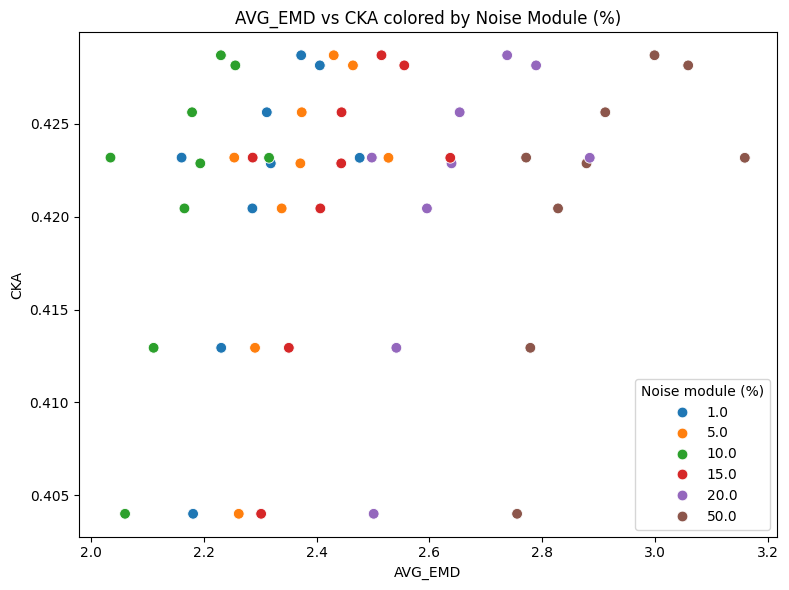

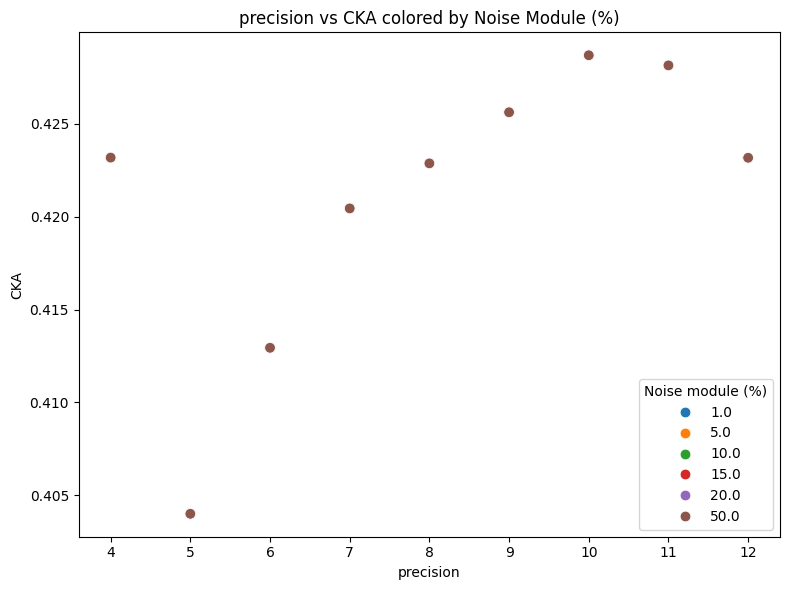

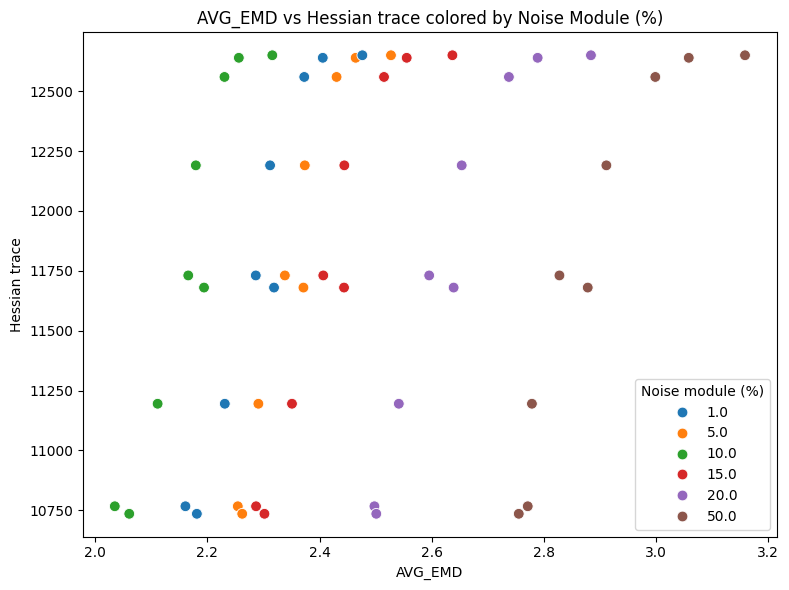

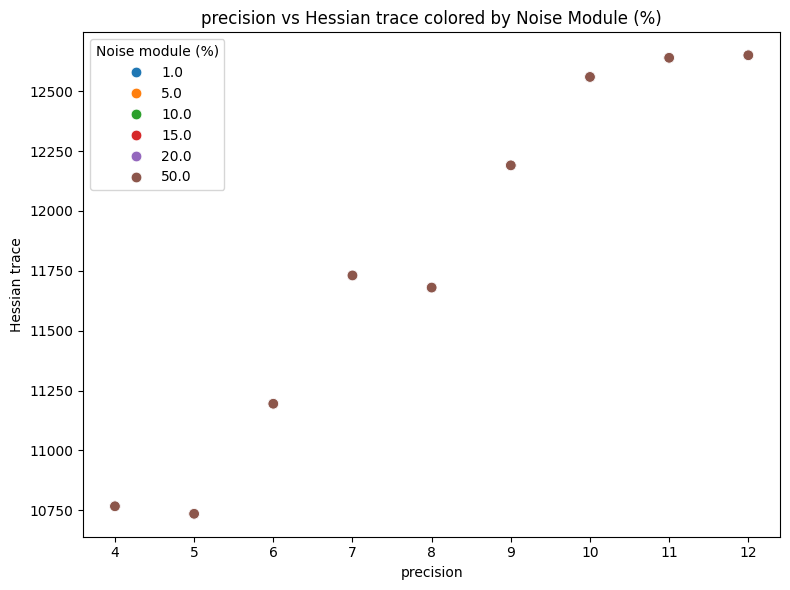

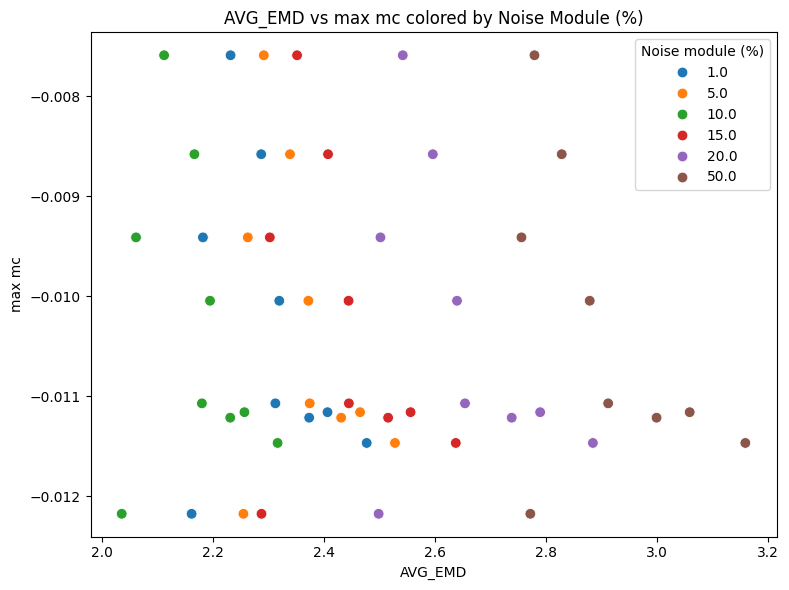

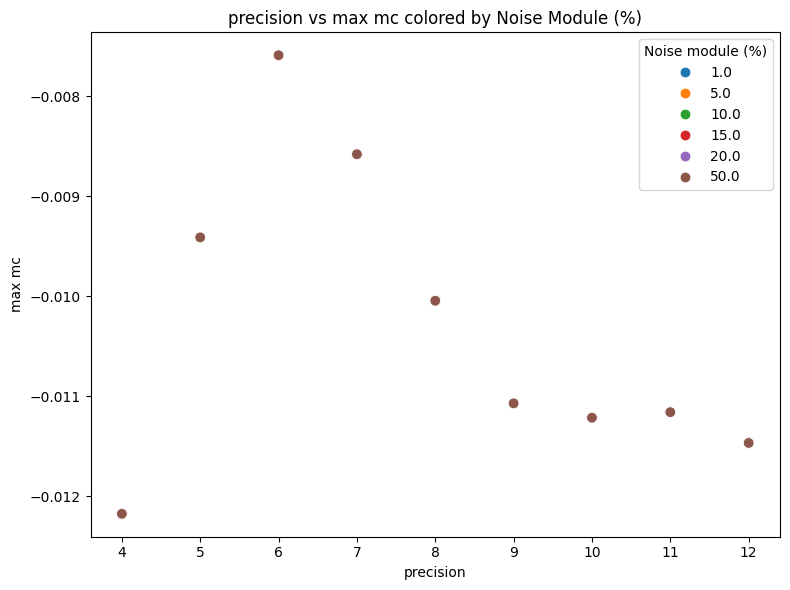

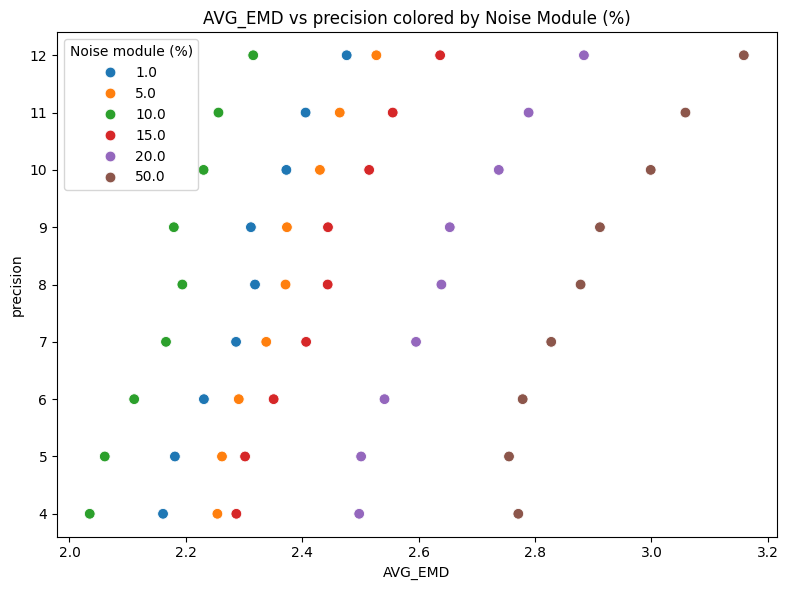

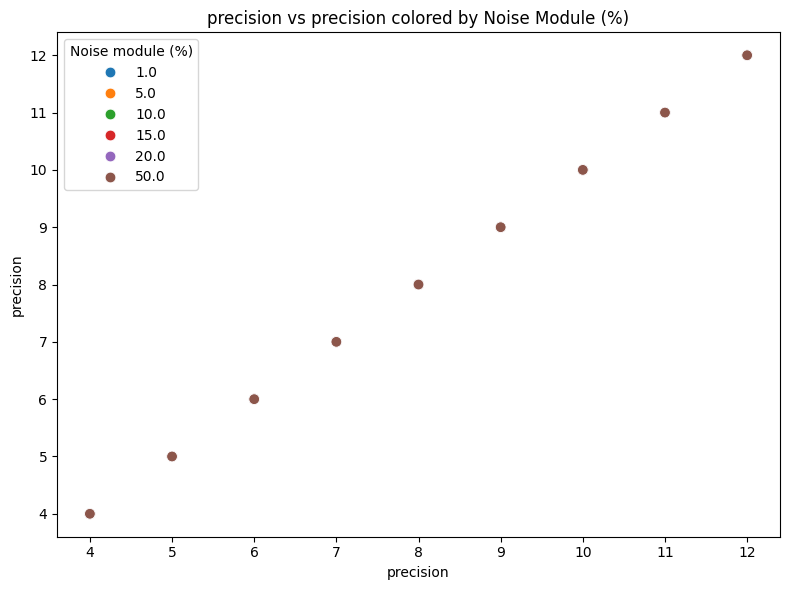

********************************************************************************
Orthogonality (δ=1e-5)


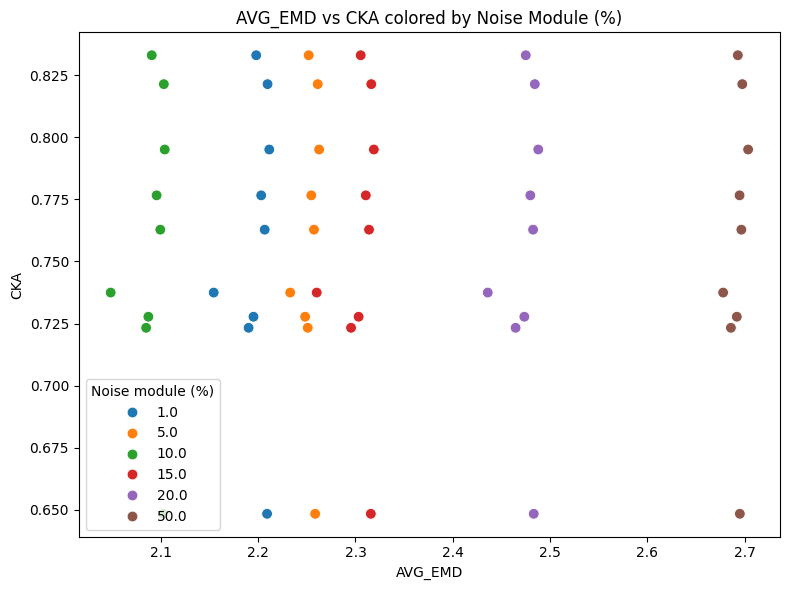

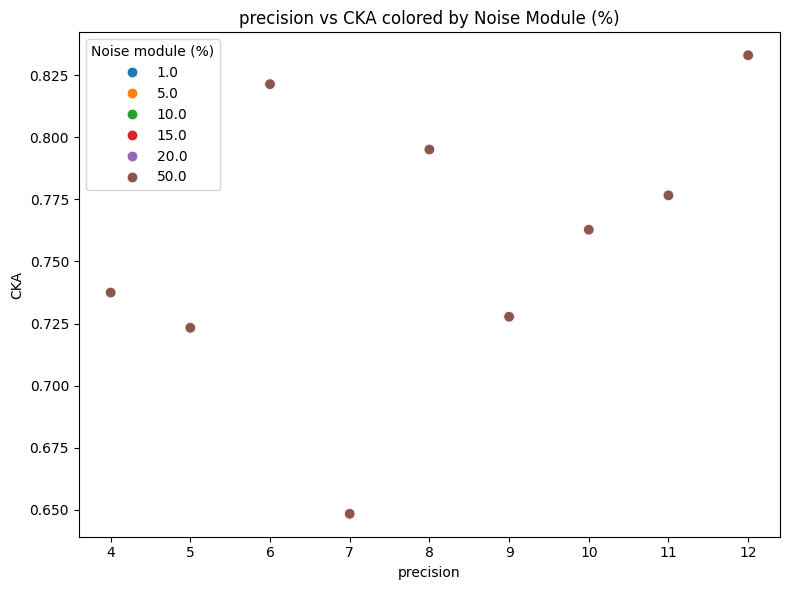

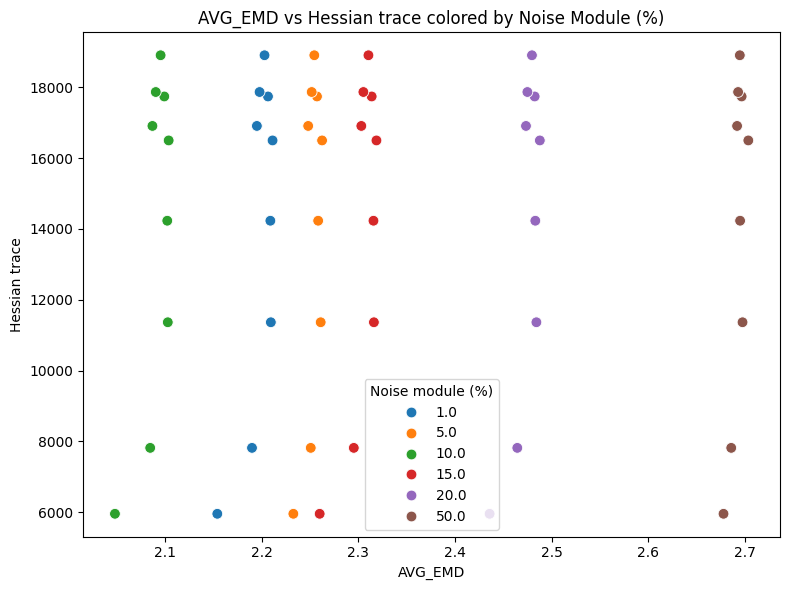

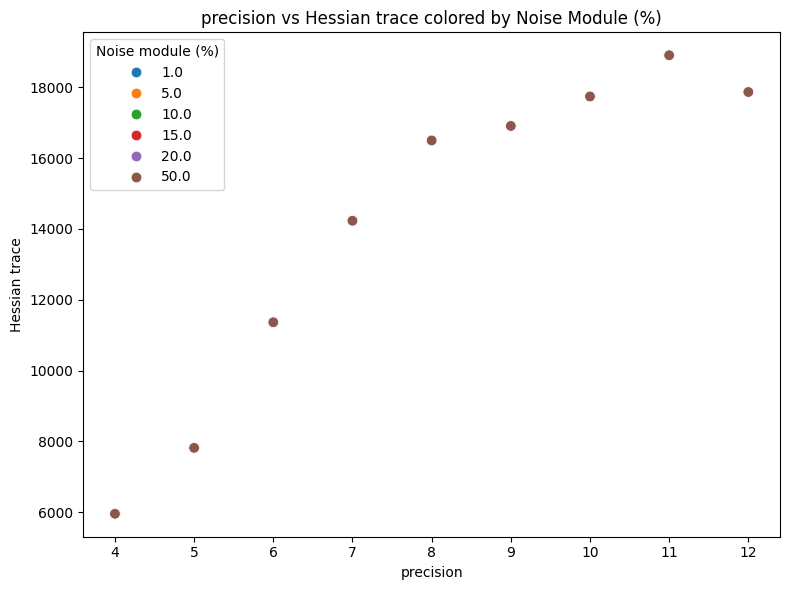

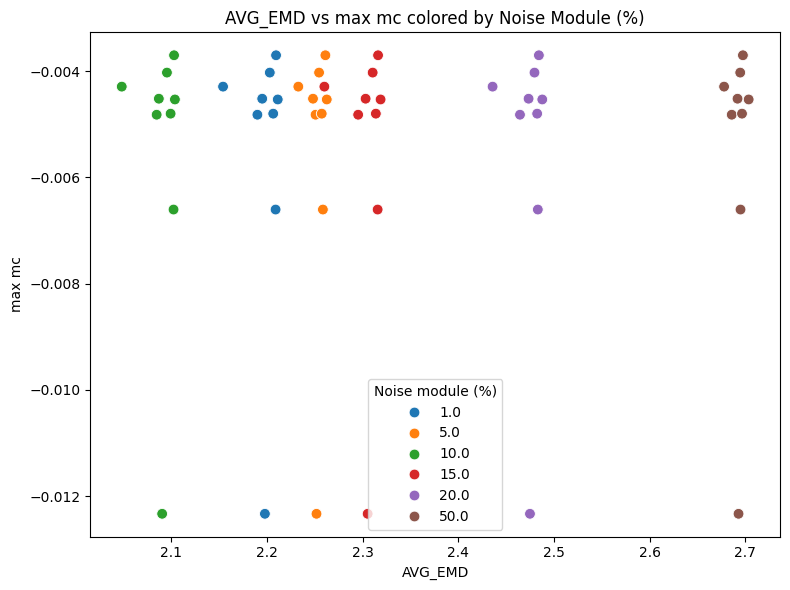

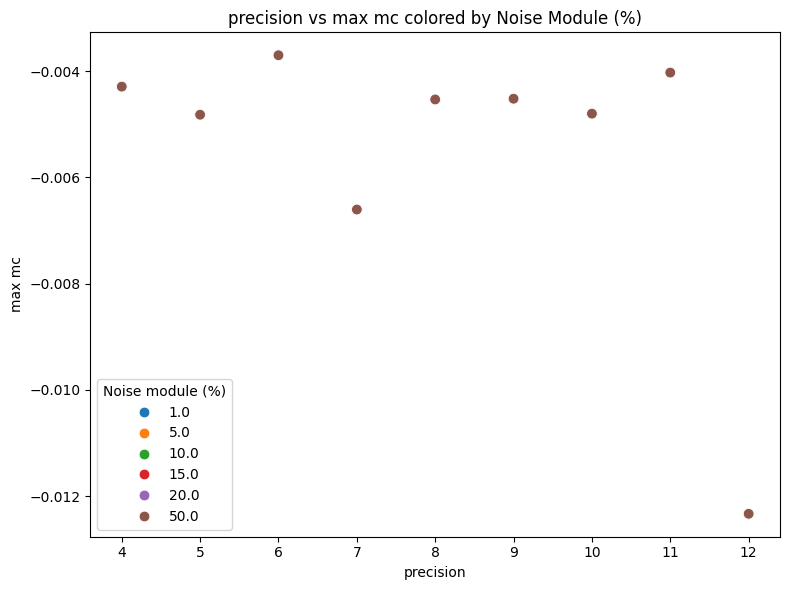

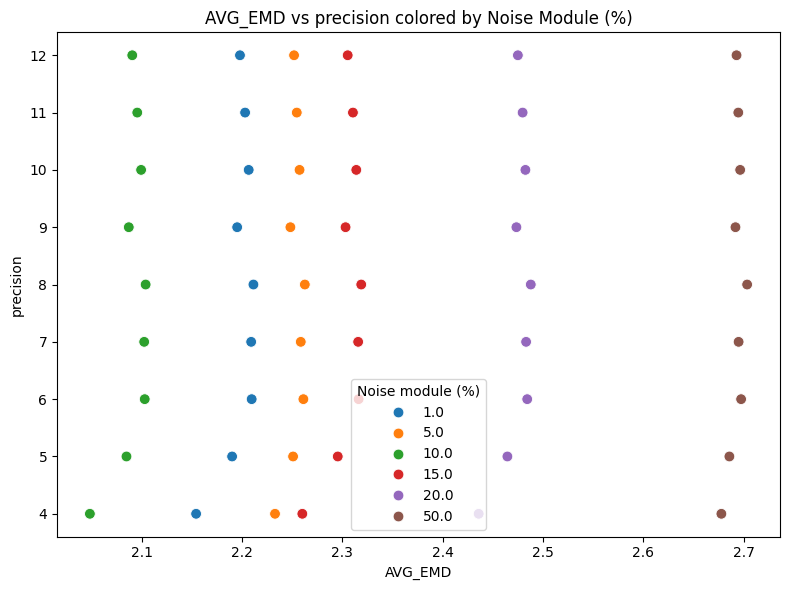

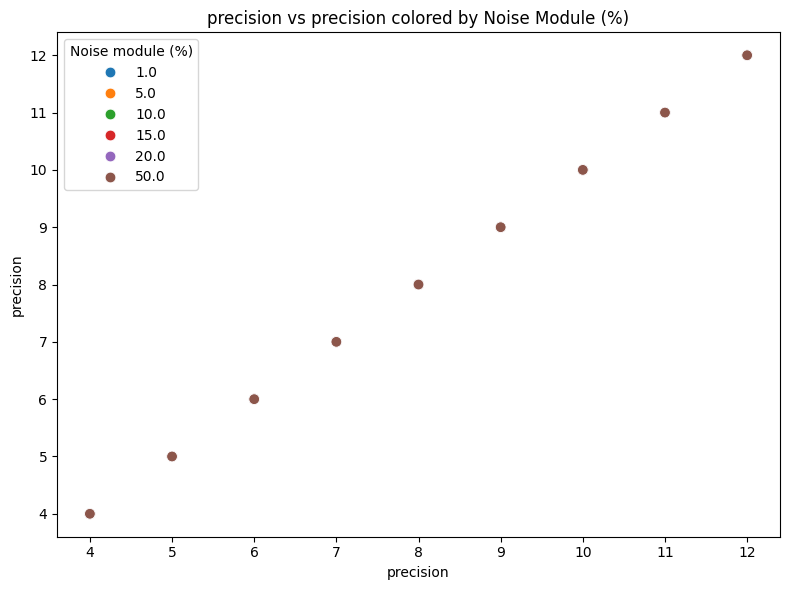

********************************************************************************
Jacobian (δ=1e-1)


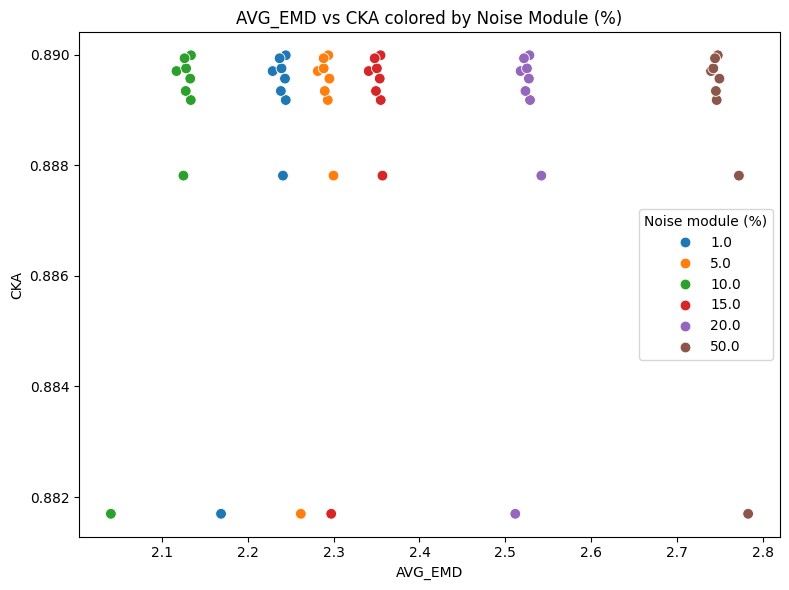

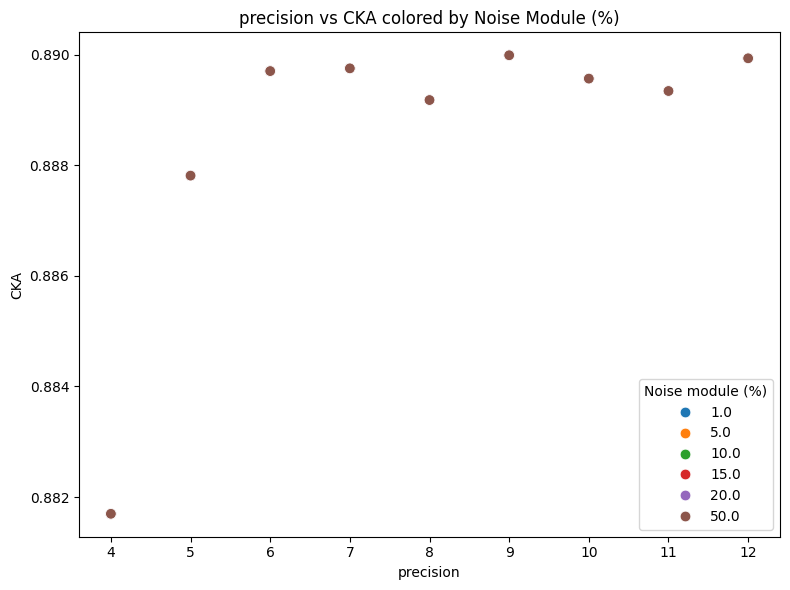

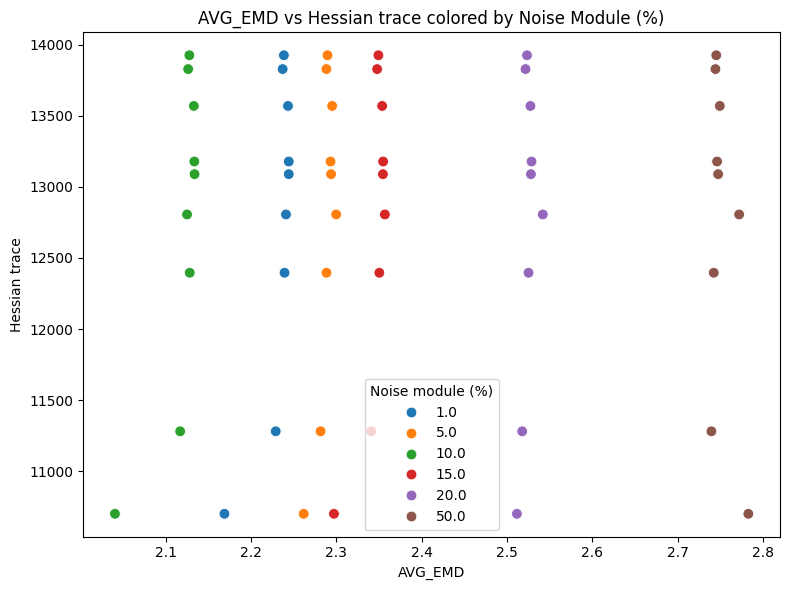

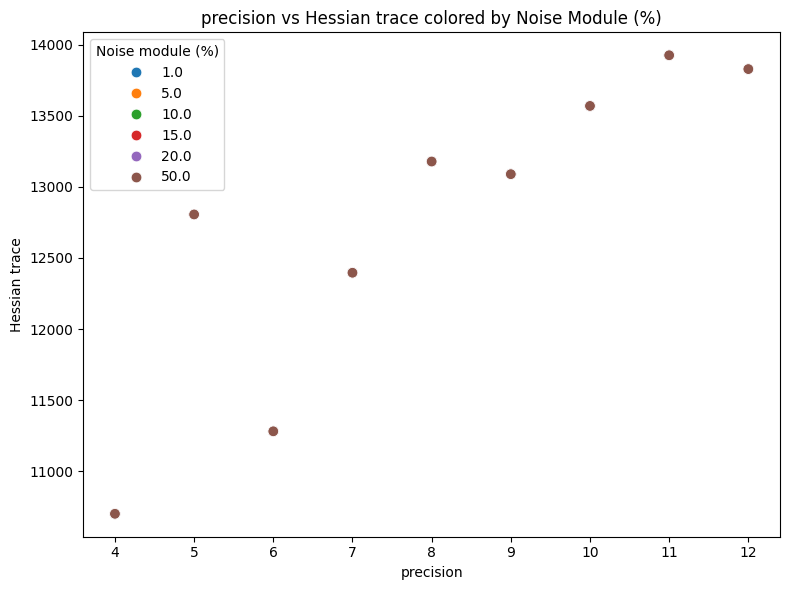

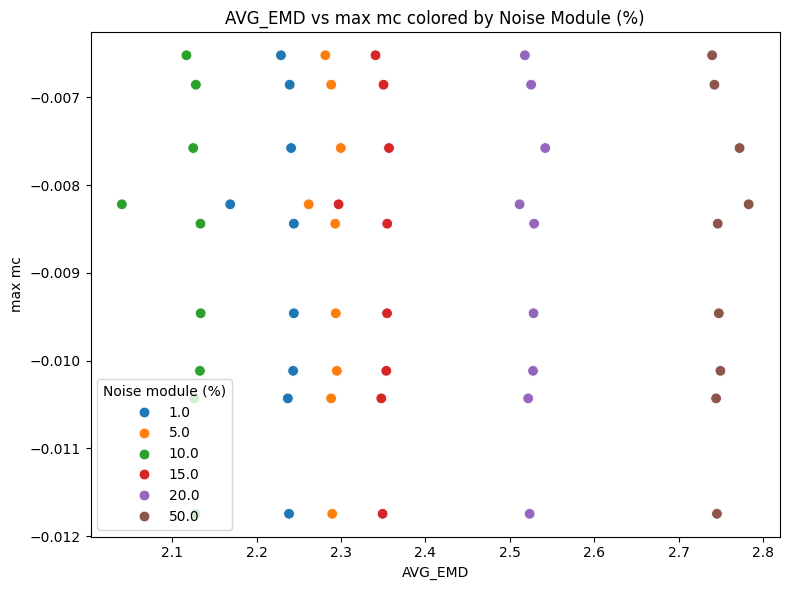

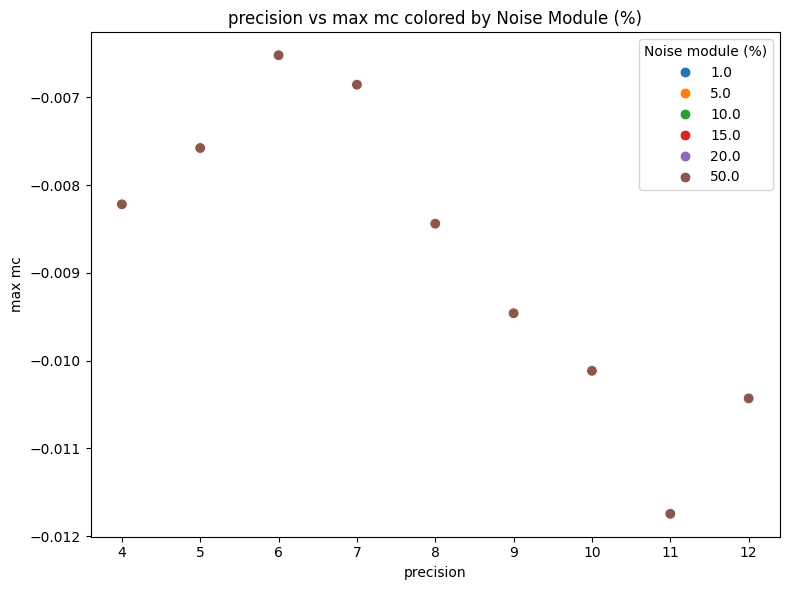

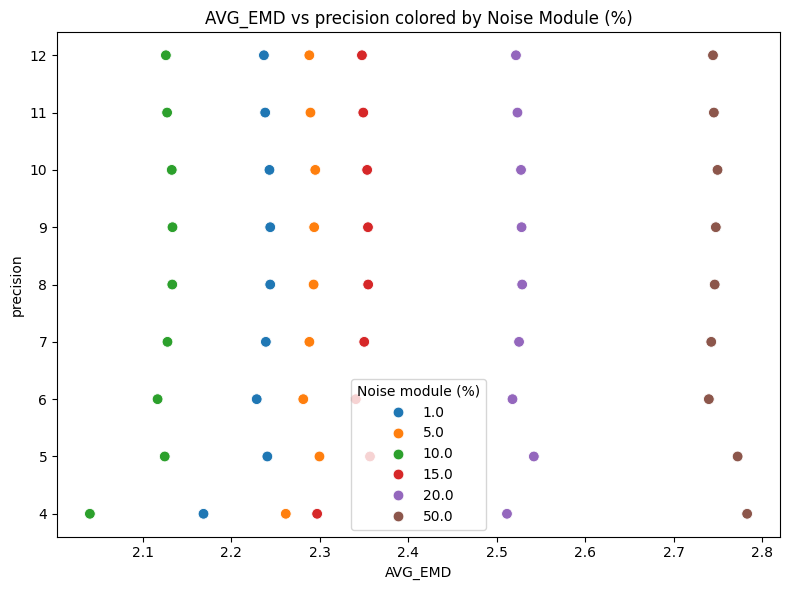

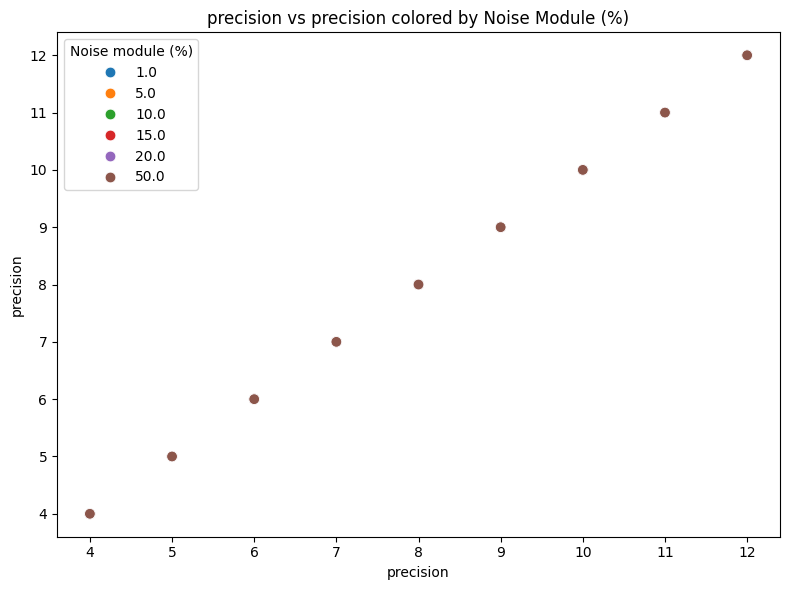

********************************************************************************
********************************************************************************
salt_pepper
********************************************************************************
Baseline


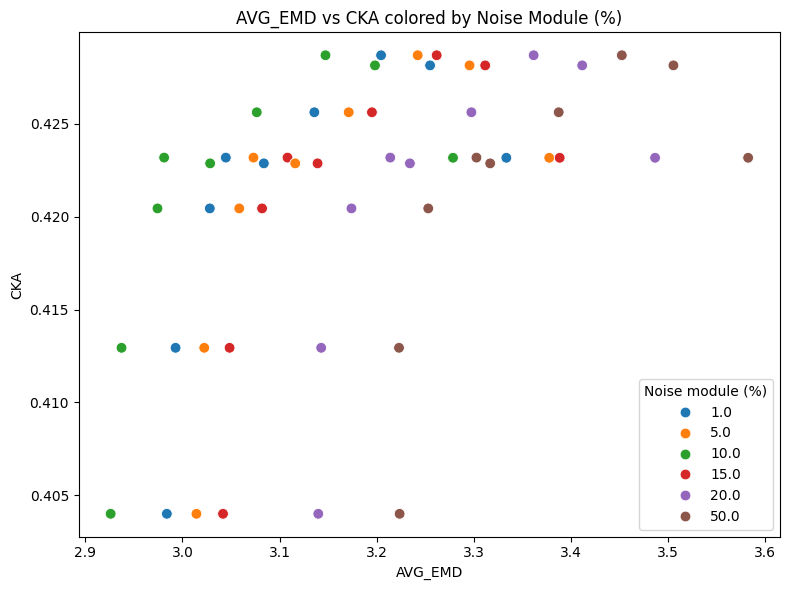

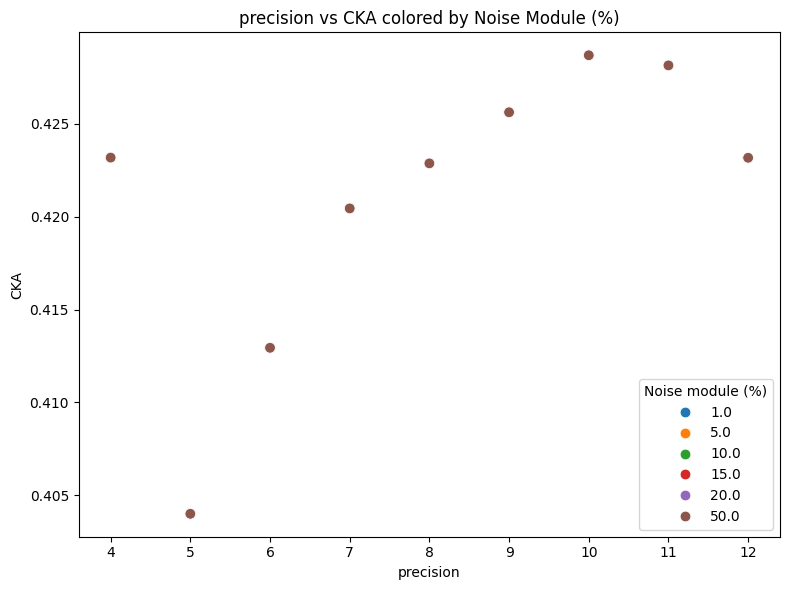

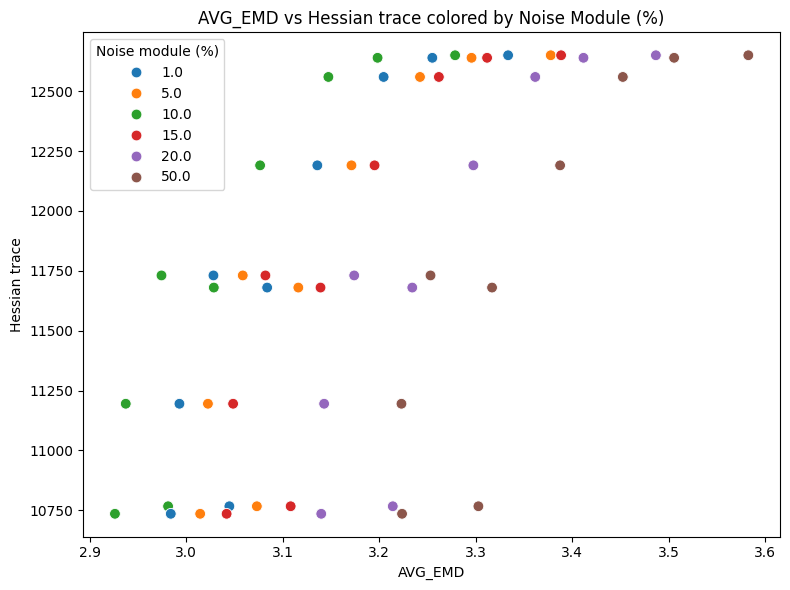

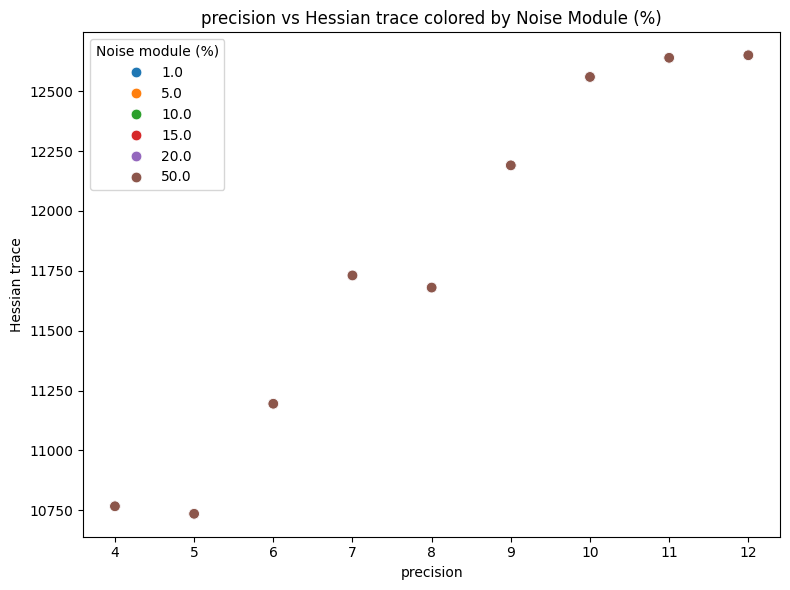

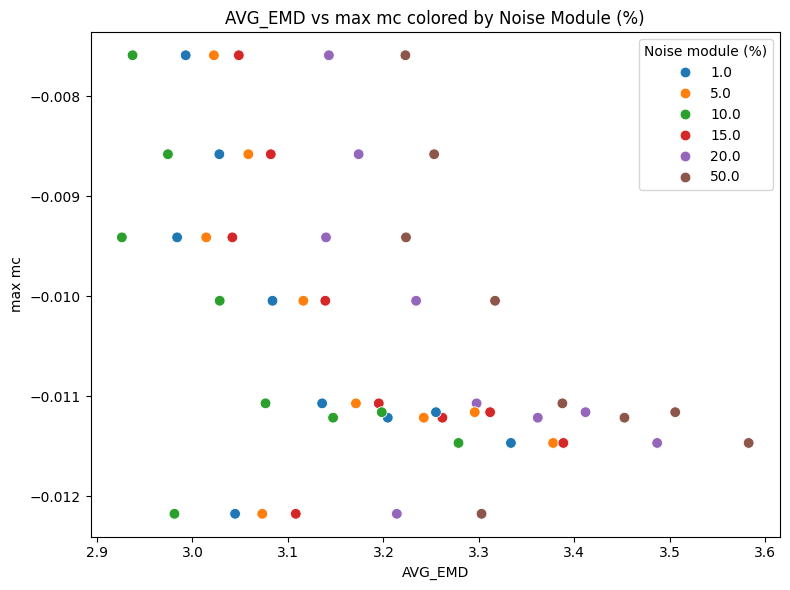

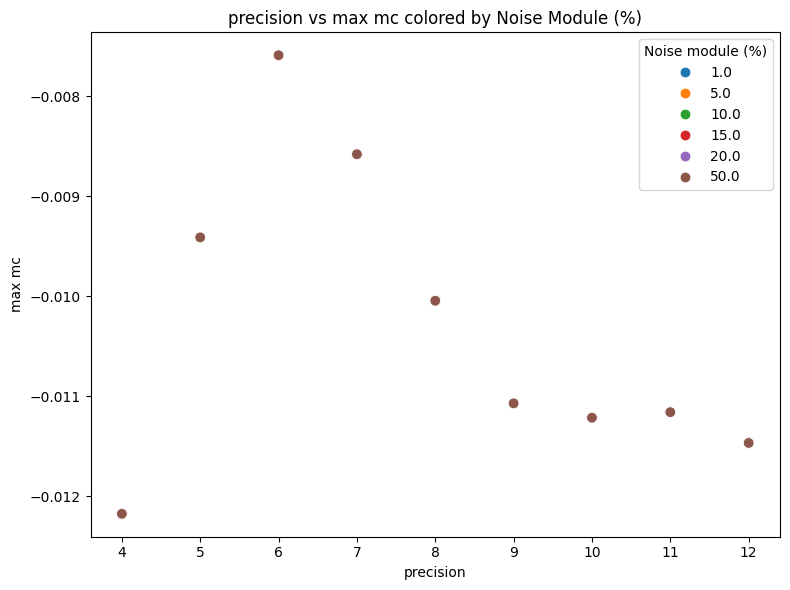

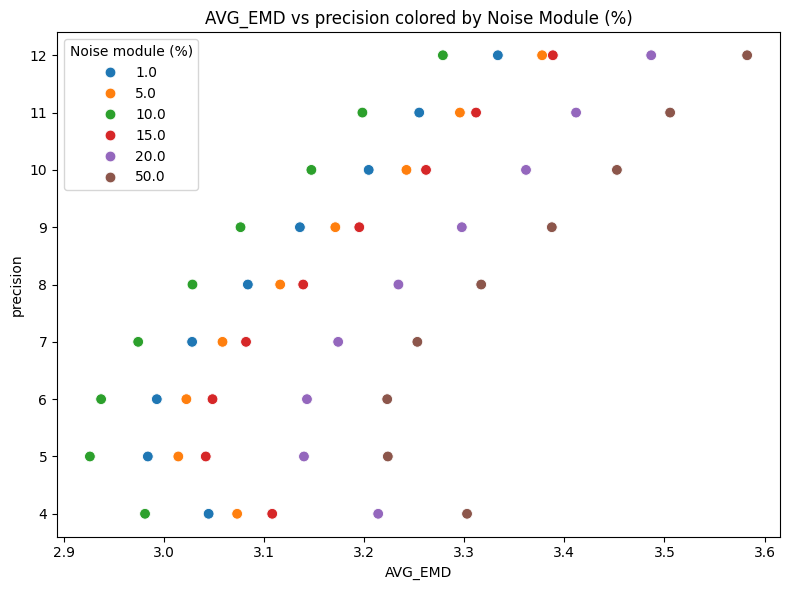

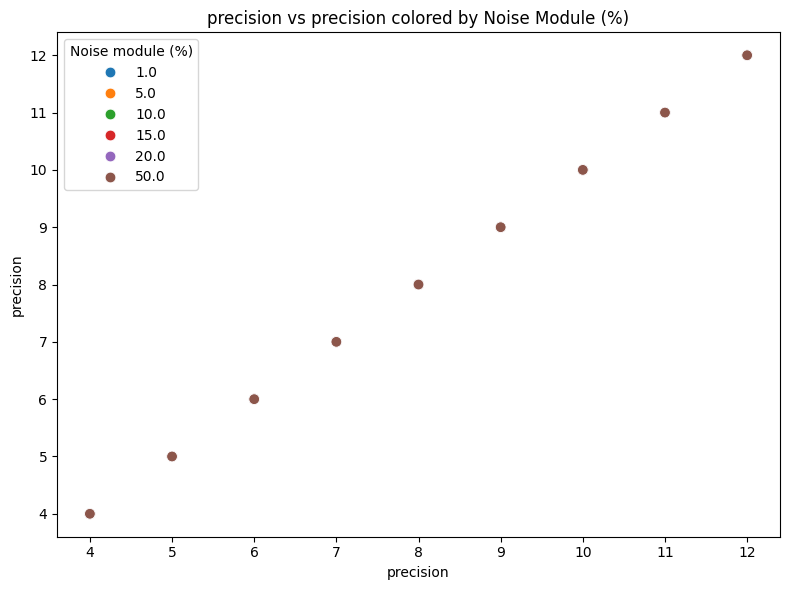

********************************************************************************
Orthogonality (δ=1e-5)


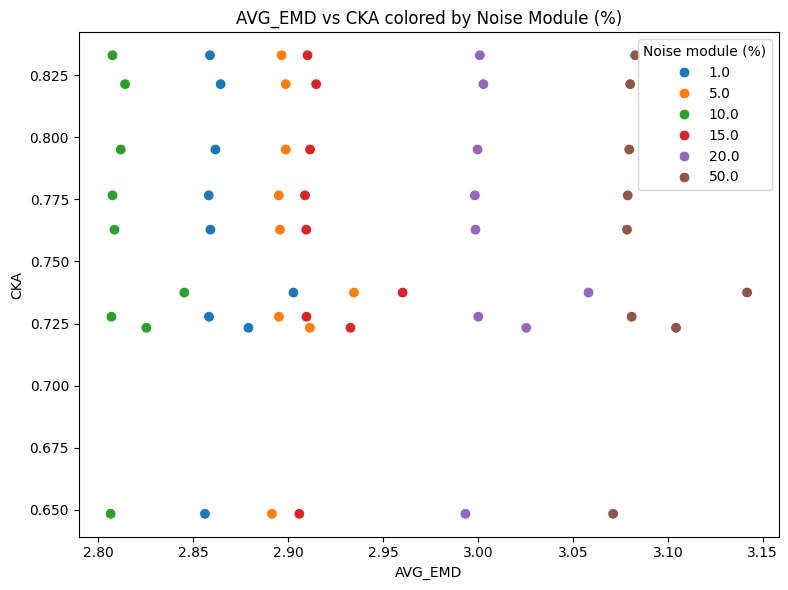

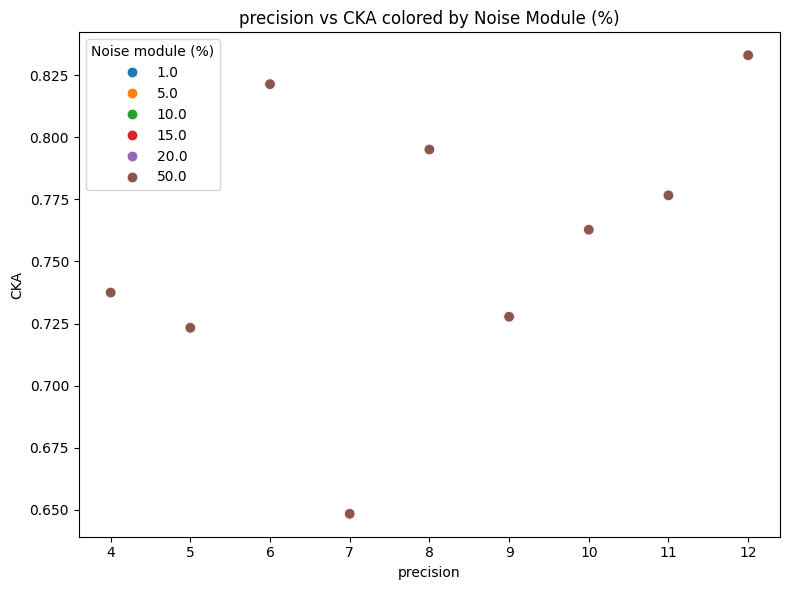

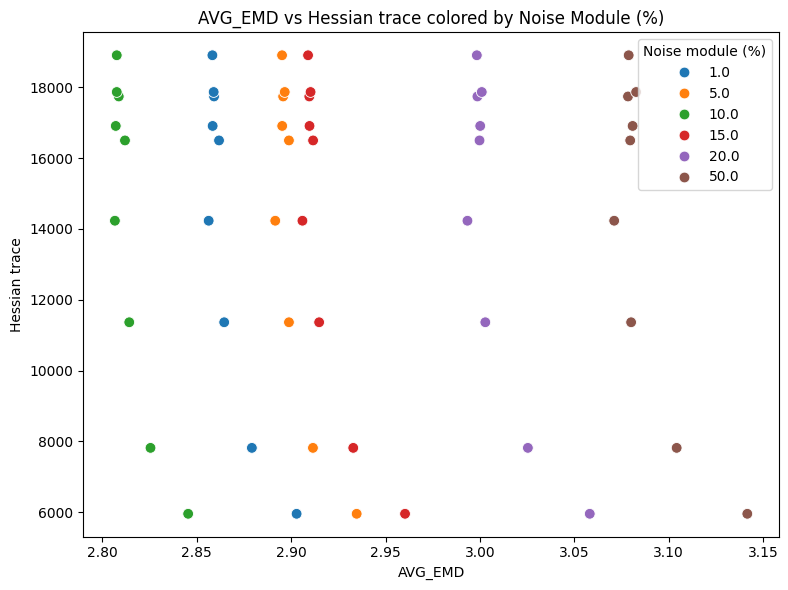

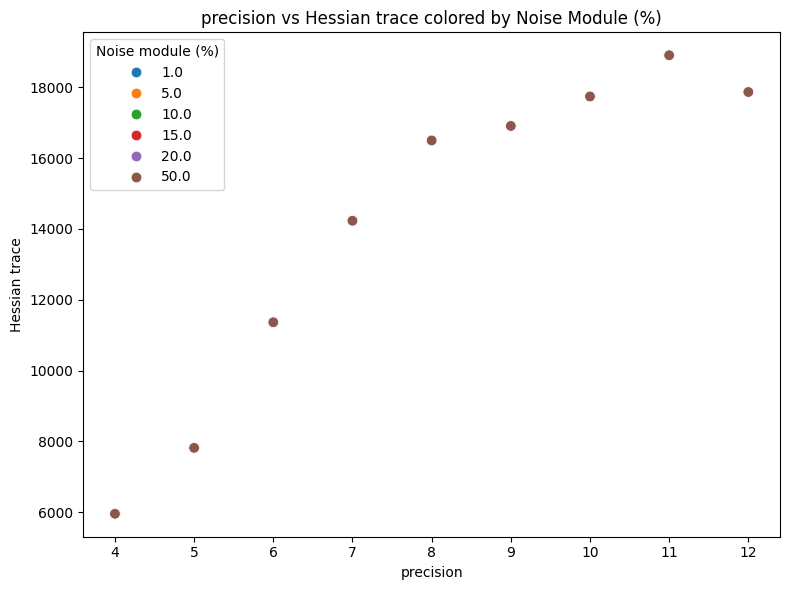

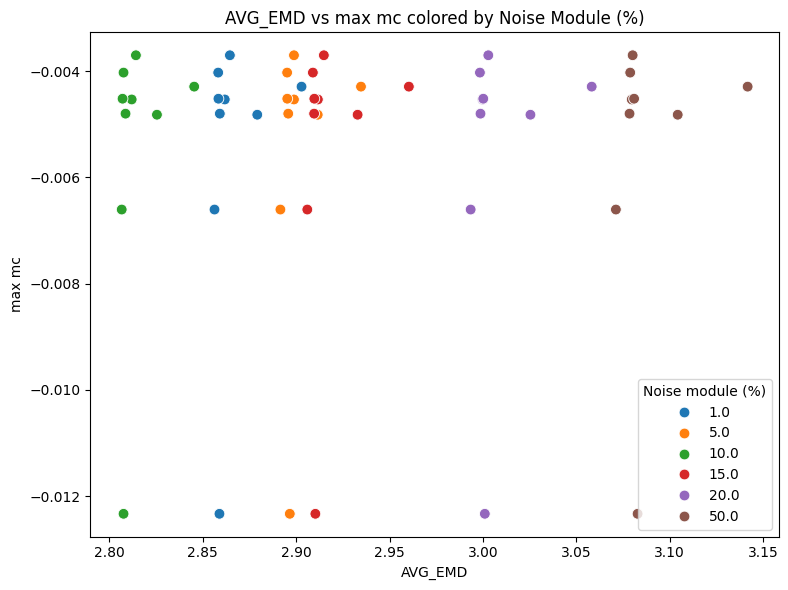

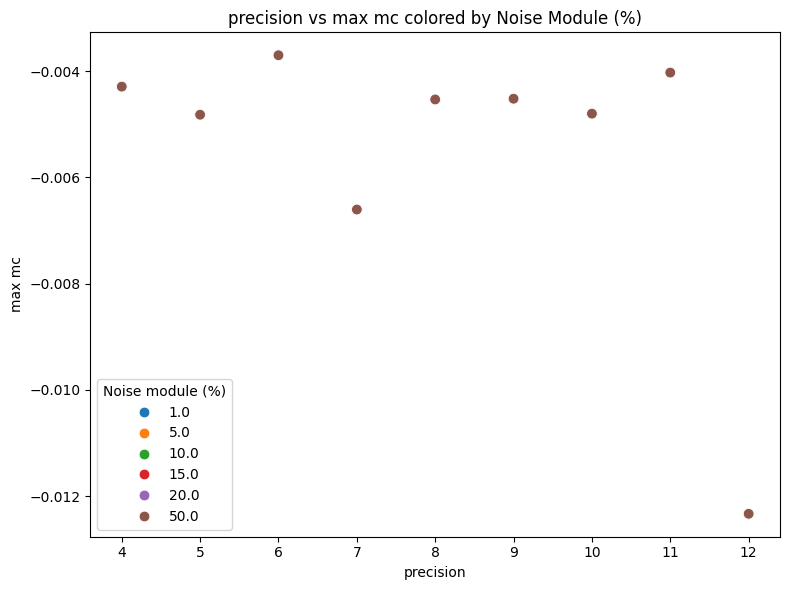

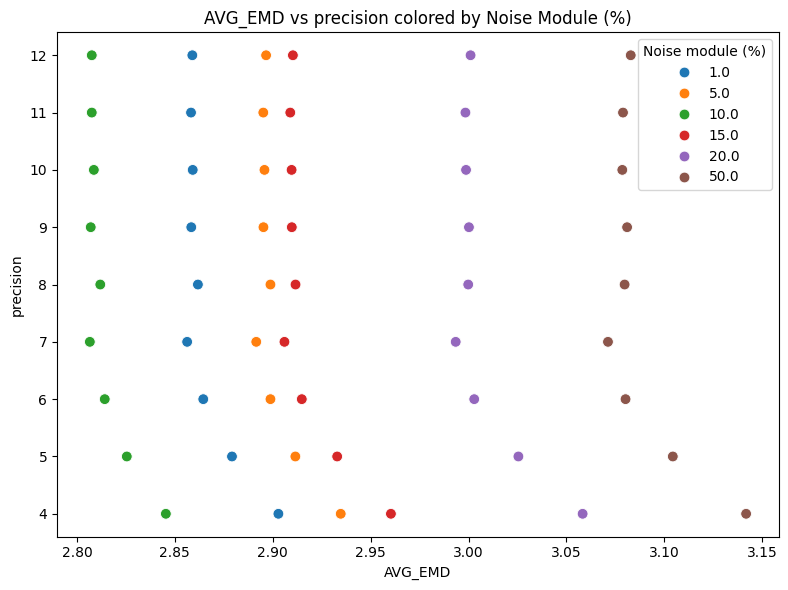

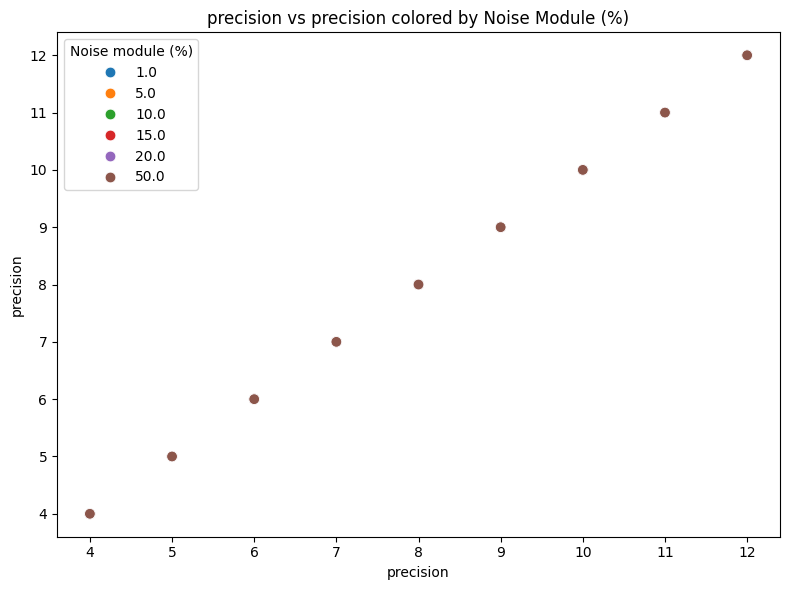

********************************************************************************
Jacobian (δ=1e-1)


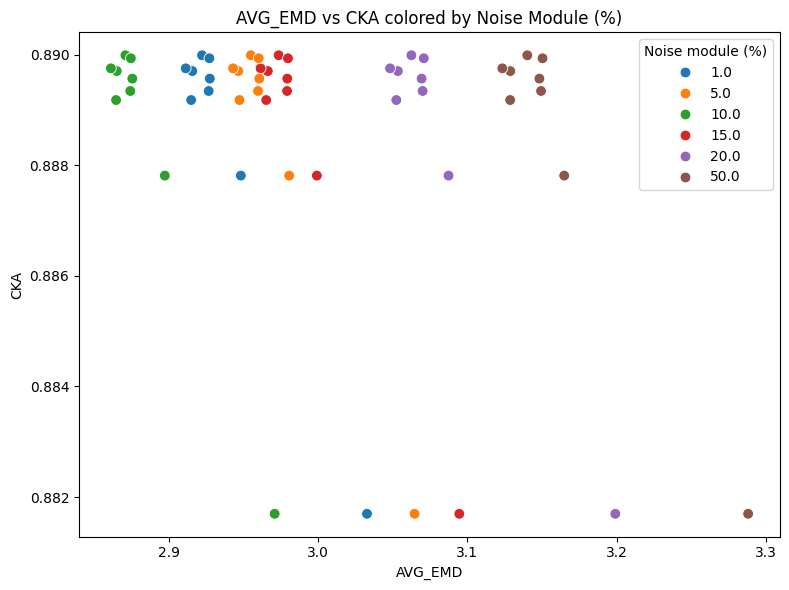

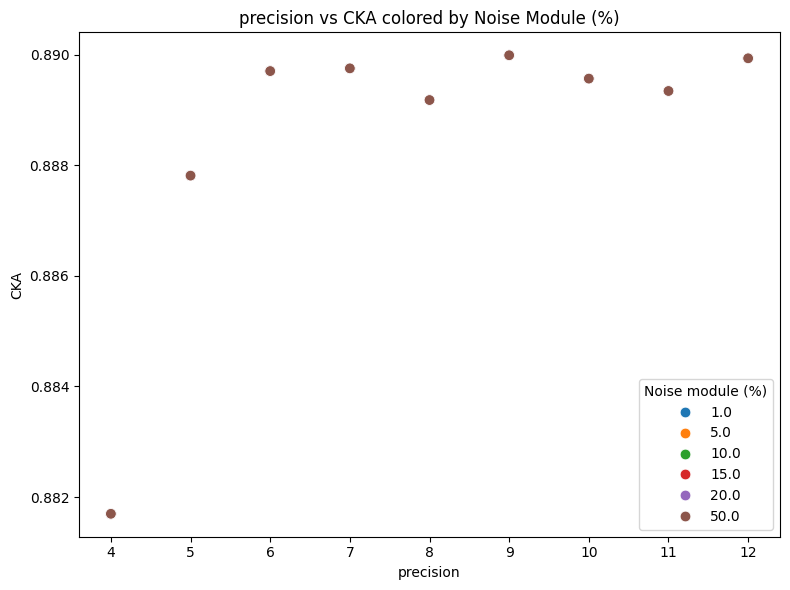

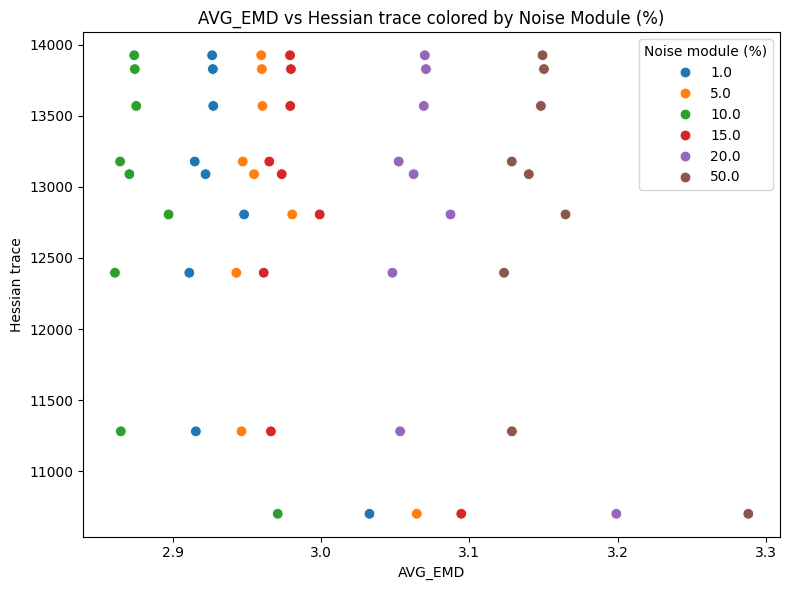

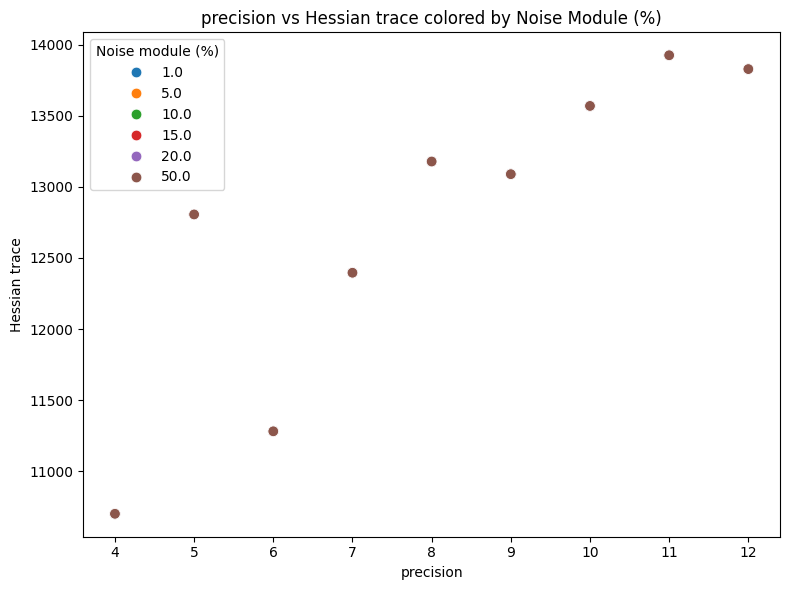

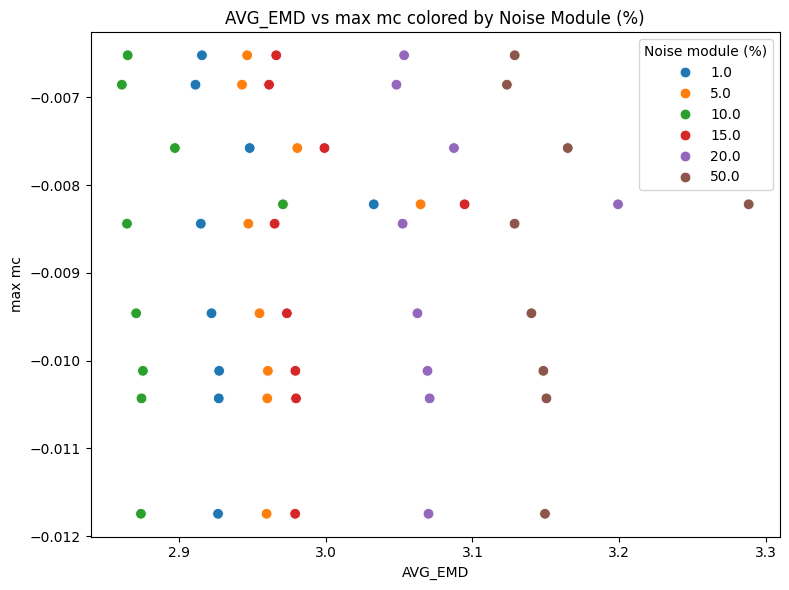

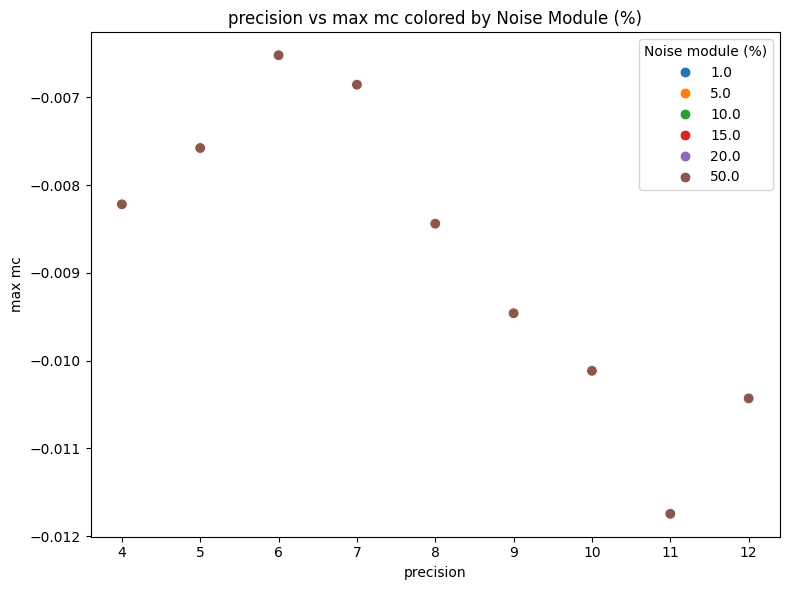

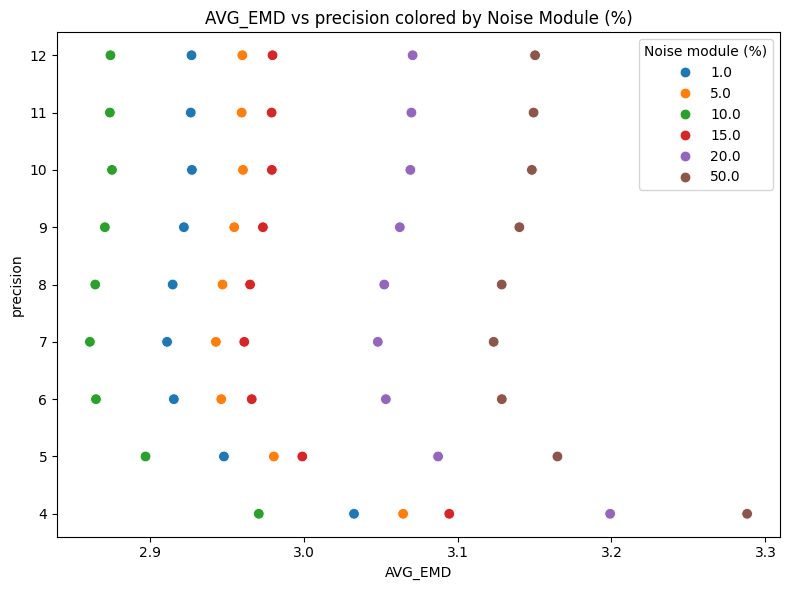

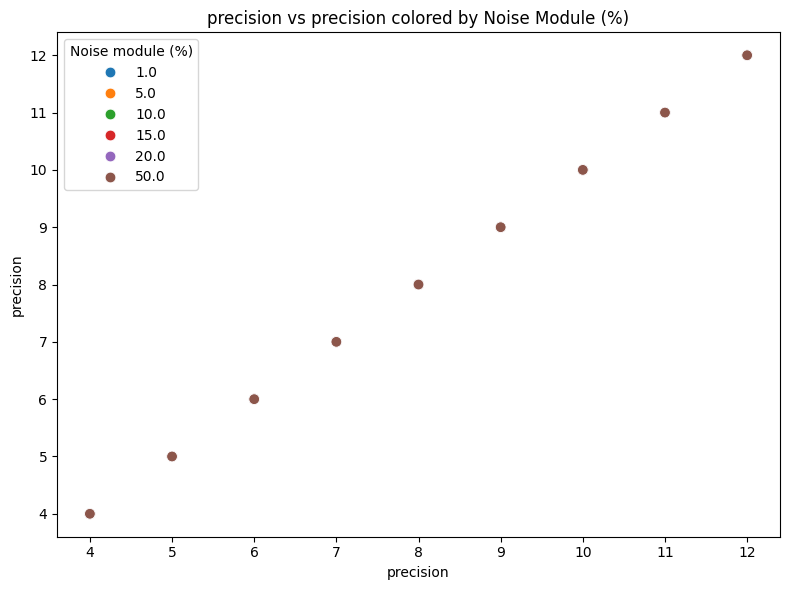

********************************************************************************


In [42]:
for noise_type in ["gaussian", "salt_pepper"]:
    print(80*"*")
    print(noise_type)
    for regularizer in ["Baseline", "Orthogonality (δ=1e-5)", "Jacobian (δ=1e-1)"]:
        print(80*"*")
        print(regularizer)
        subset = metric_vs_noise_df[
                    (metric_vs_noise_df["regularizer"] == regularizer) &
                    (metric_vs_noise_df["noise_type"].isin(["clean", noise_type]))
                ]
        
        for metric in ["CKA", "Hessian trace", "max mc", "precision"]:
            for x in ["AVG_EMD", "precision"]:
                plt.figure(figsize=(8, 6))

                sns.scatterplot(
                    data=subset,
                    x=x,
                    y=metric,
                    hue="Noise module (%)",
                    palette="tab10",
                    s=60
                )

                plt.title(f"{x} vs {metric} colored by Noise Module (%)")
                plt.xlabel(x)
                plt.ylabel(metric)
                plt.legend(title="Noise module (%)")
                plt.tight_layout()
                plt.show()
    print(80*"*")
            


/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


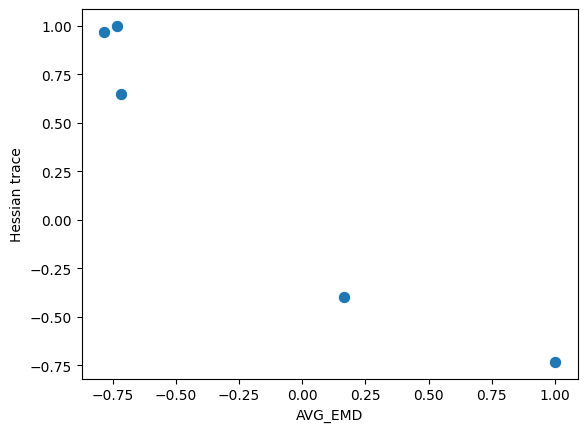

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


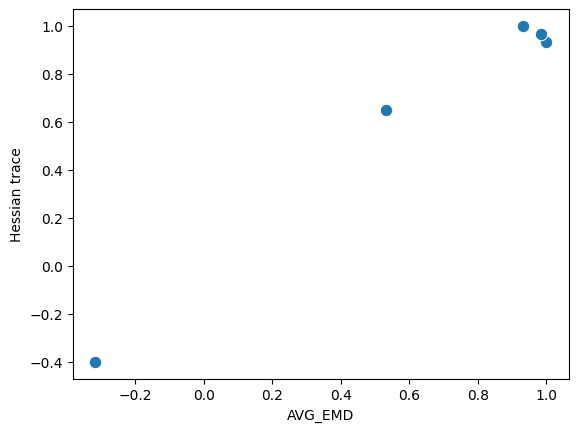

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


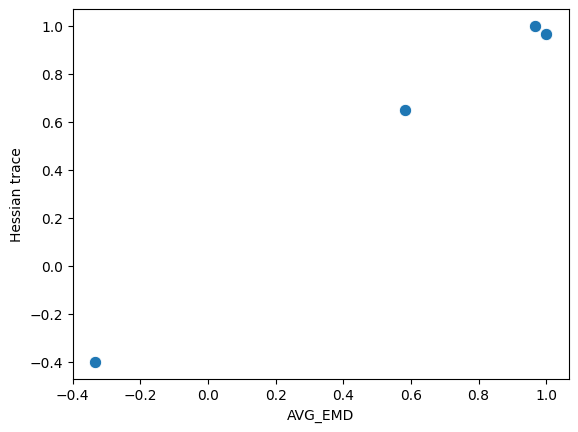

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


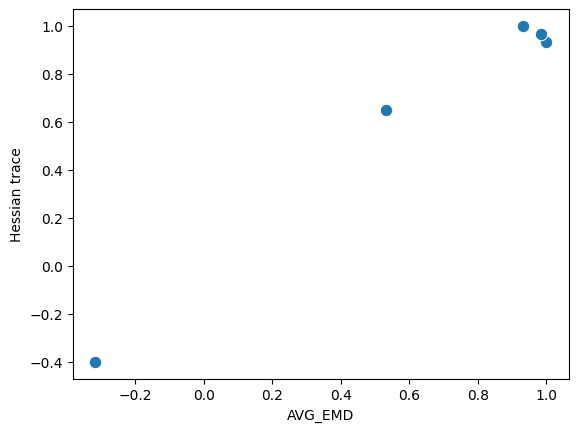

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


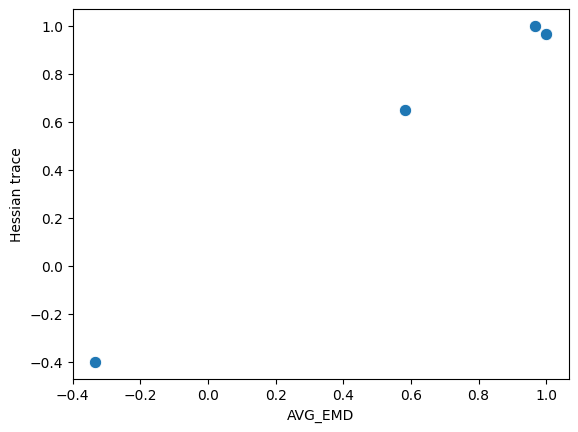

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


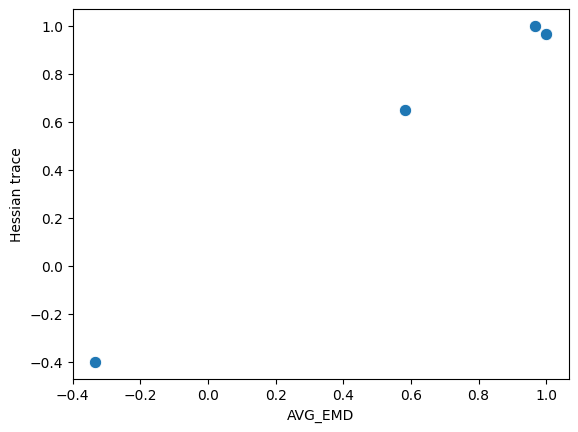

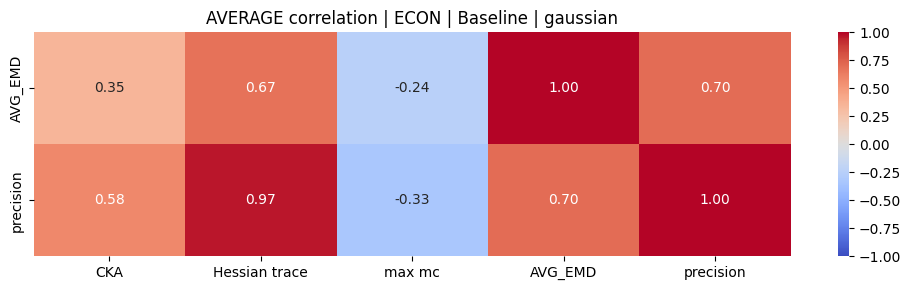

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


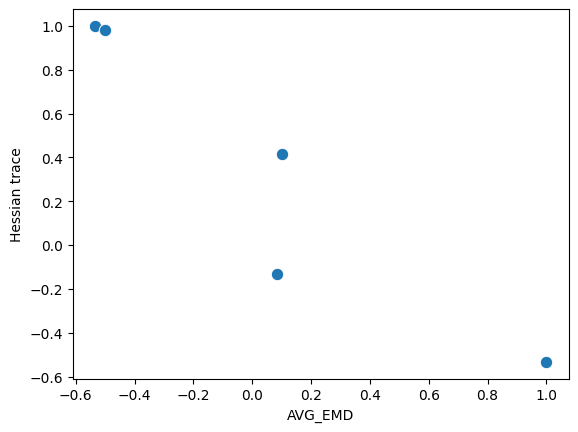

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


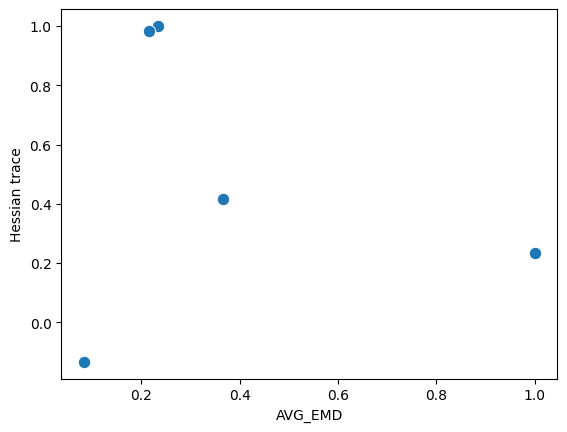

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


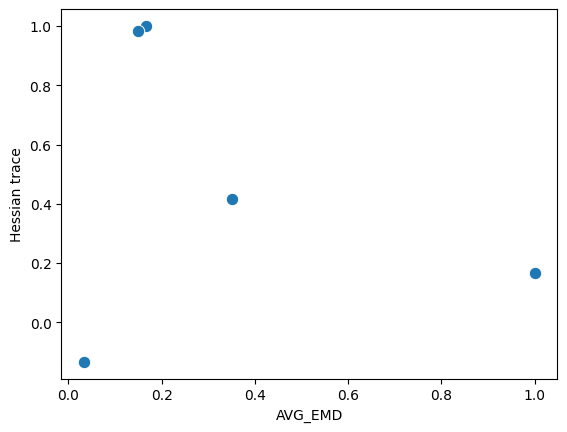

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


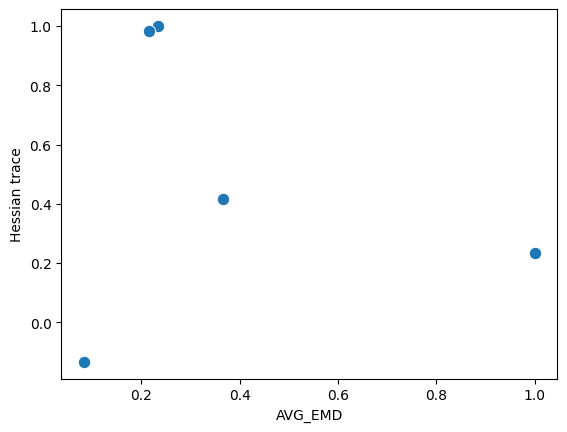

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


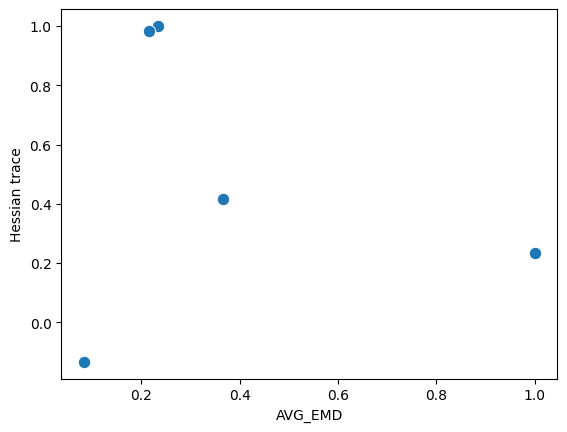

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


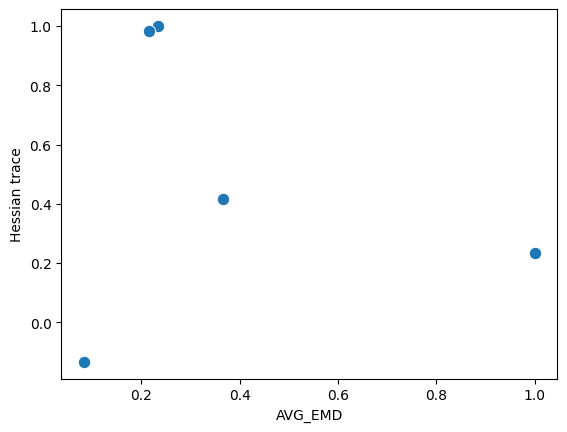

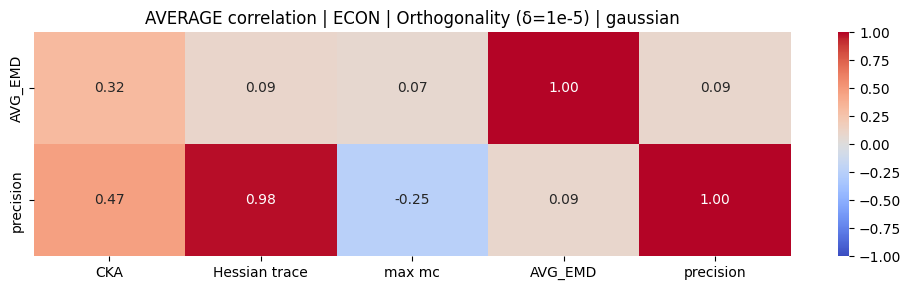

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


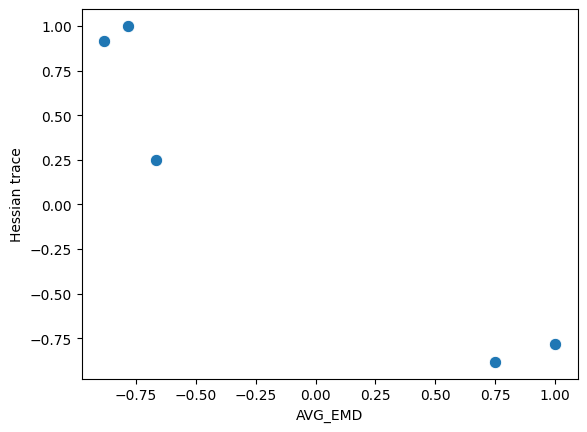

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


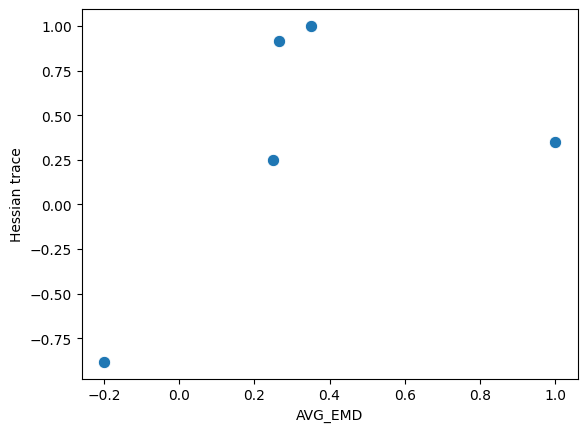

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


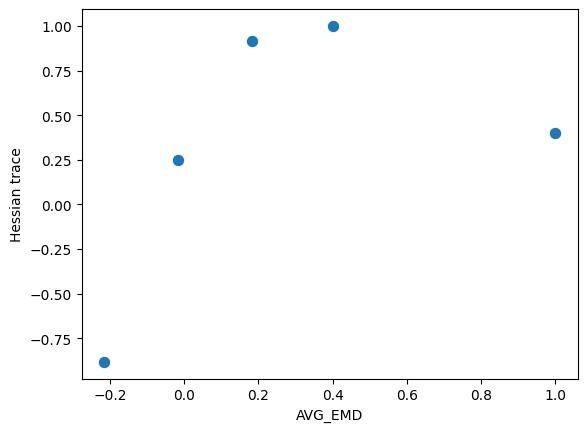

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


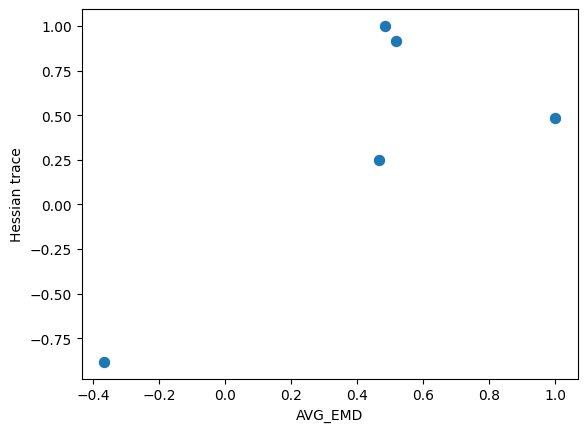

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


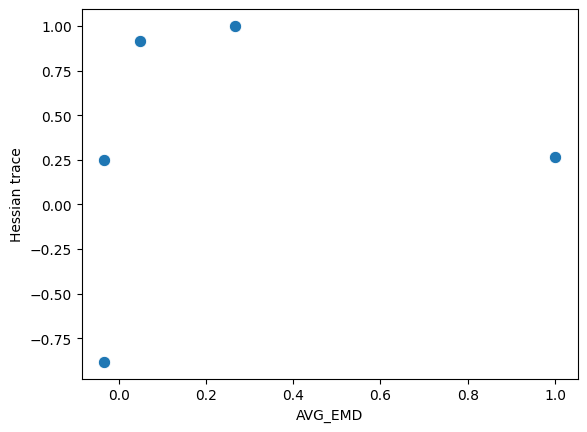

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


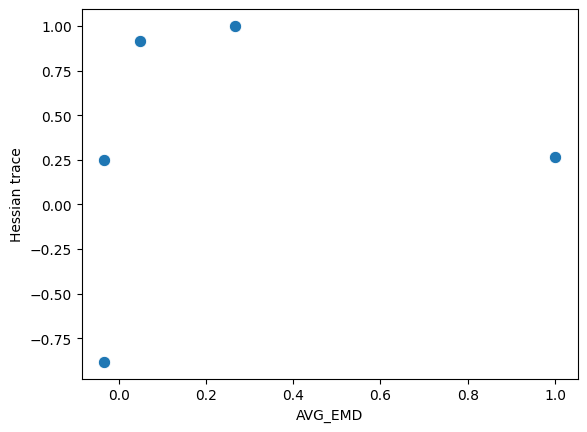

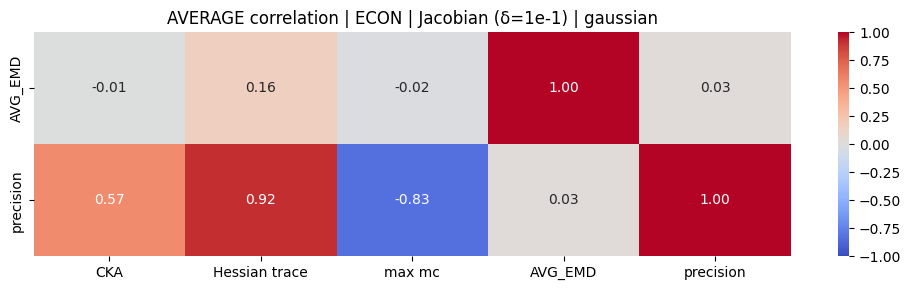

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


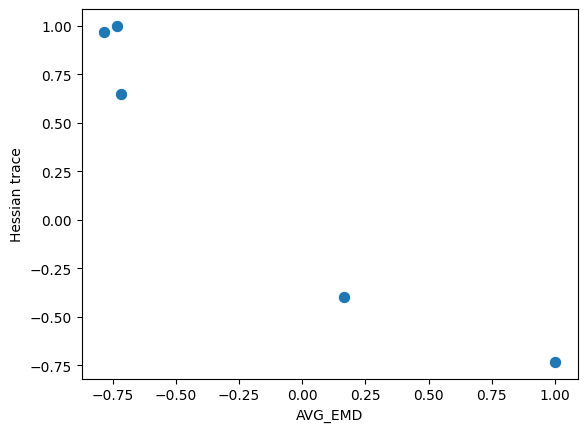

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


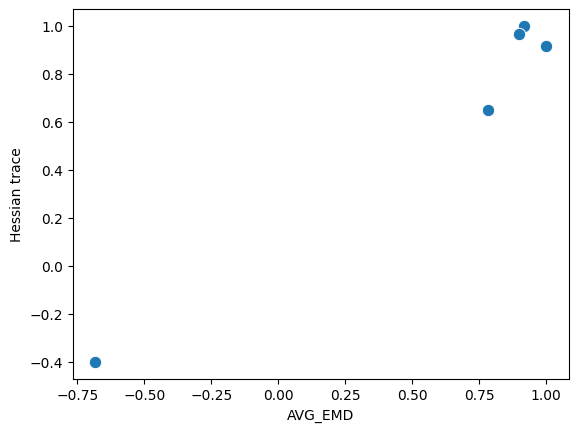

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


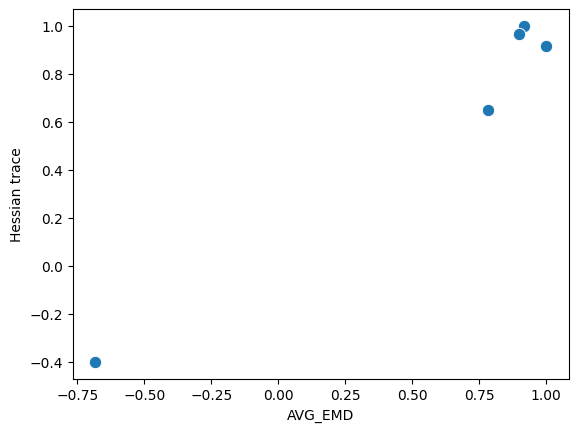

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


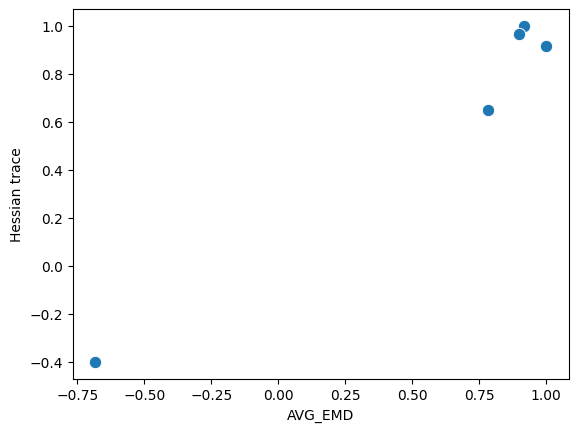

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


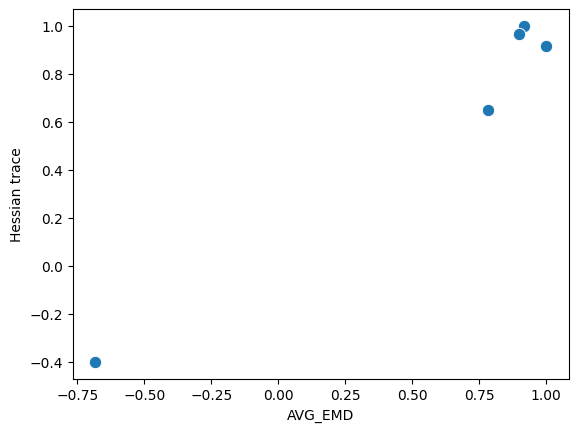

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


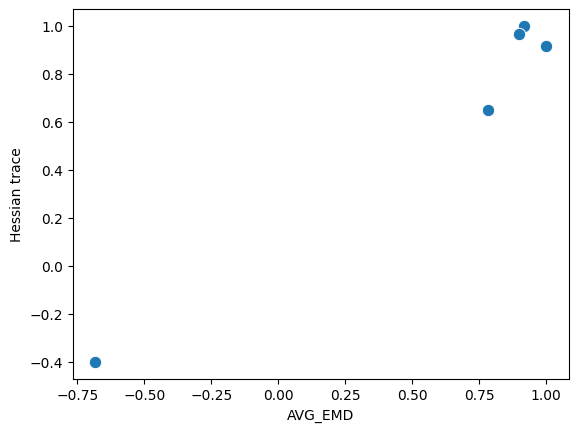

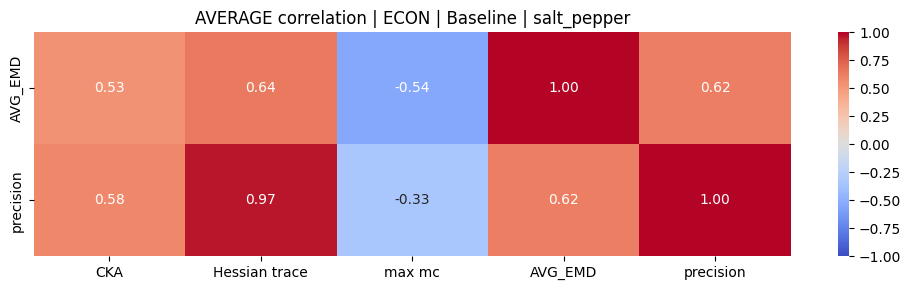

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


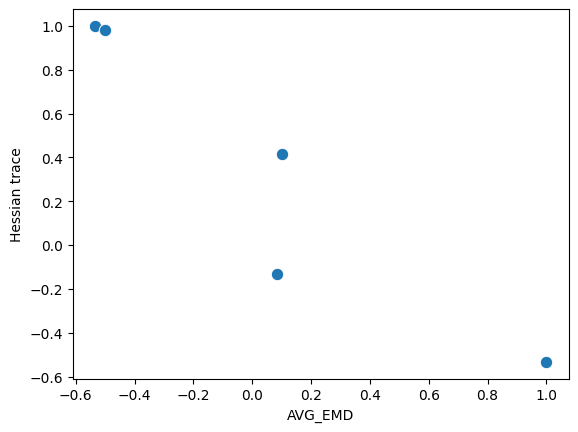

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


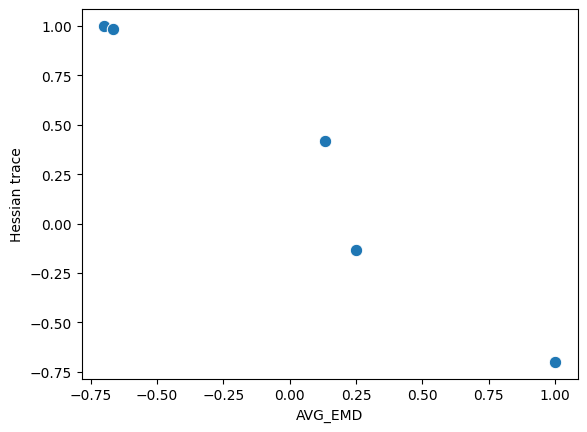

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


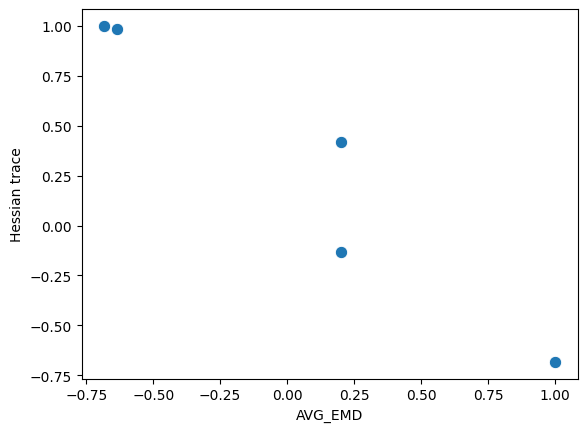

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


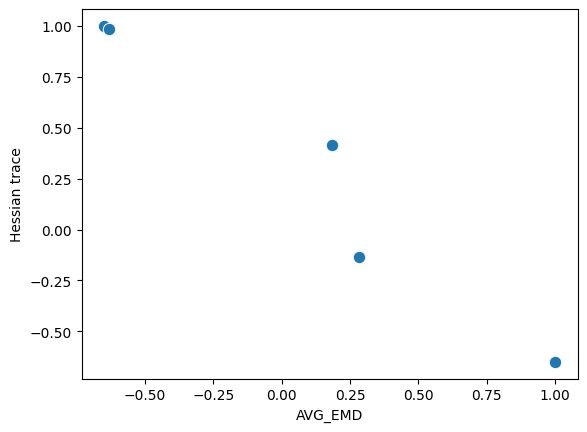

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


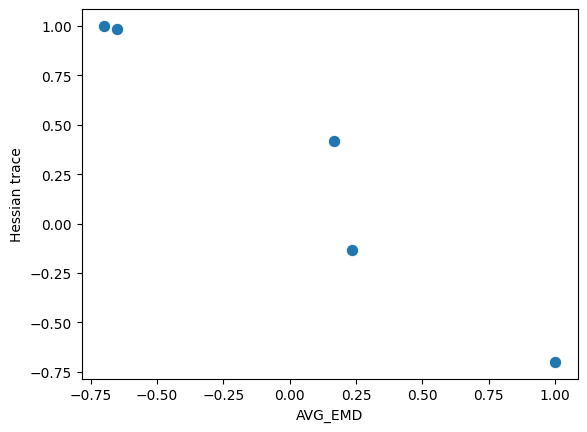

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


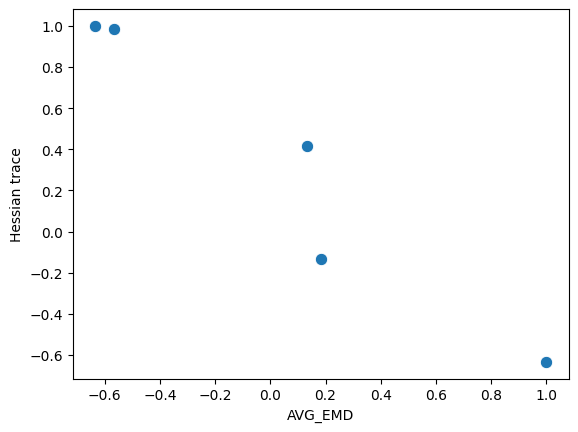

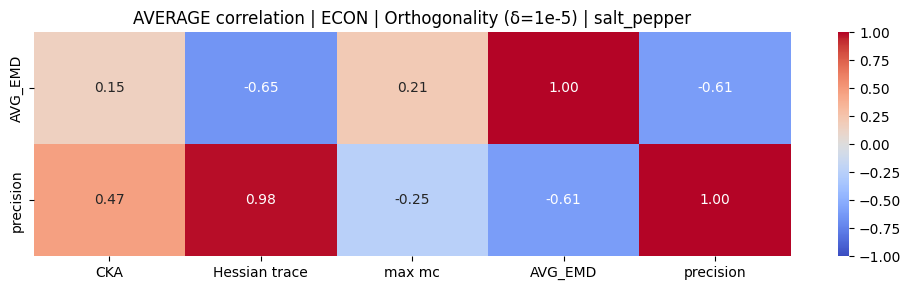

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


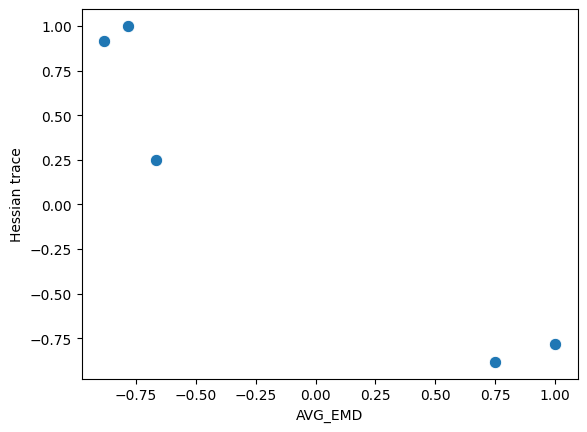

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


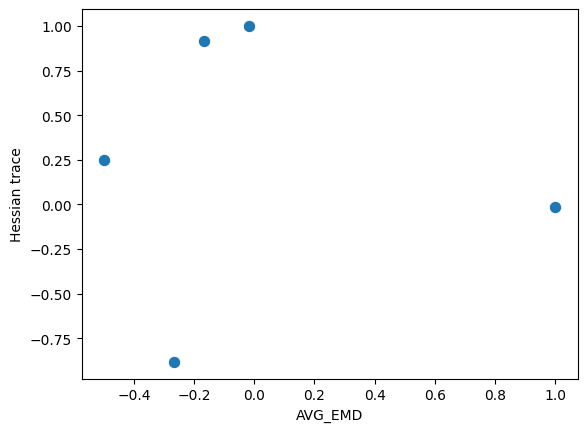

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


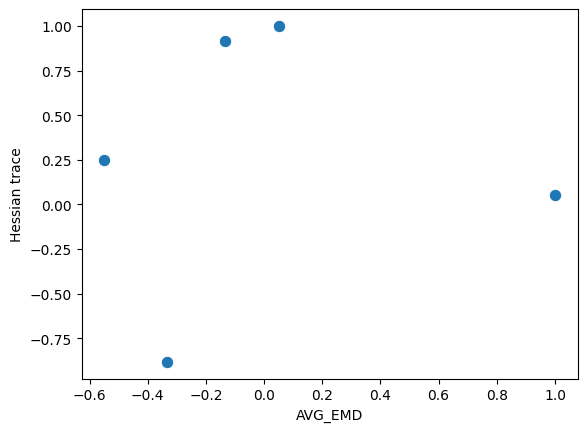

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


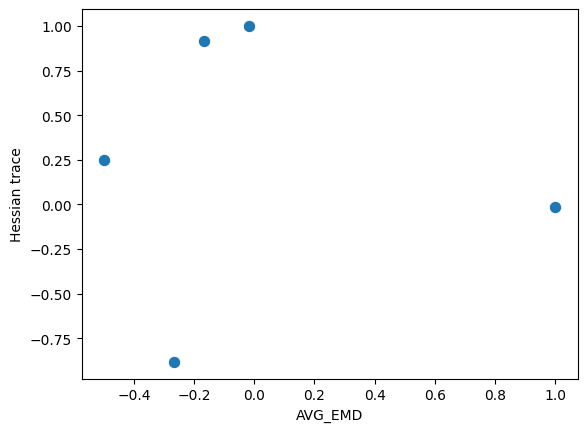

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


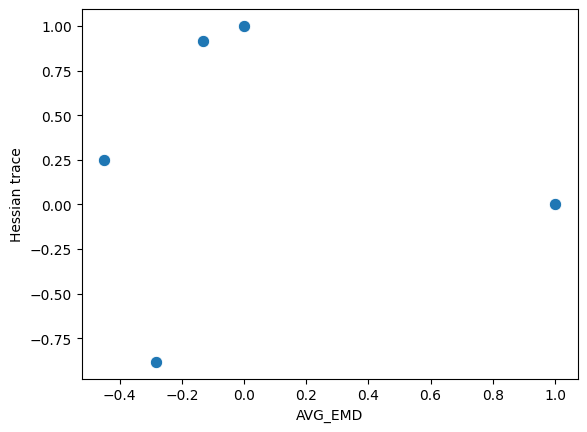

/tmp/ipykernel_35266/2535771267.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)


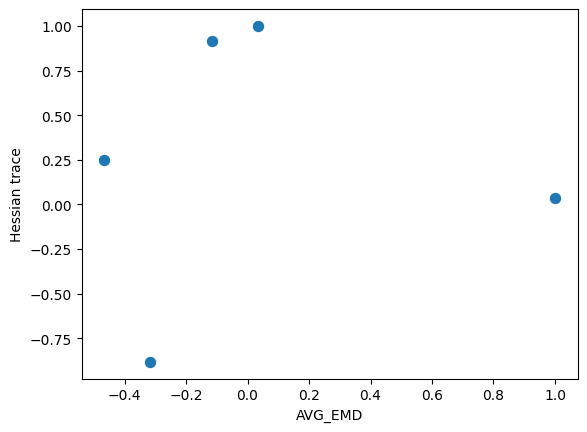

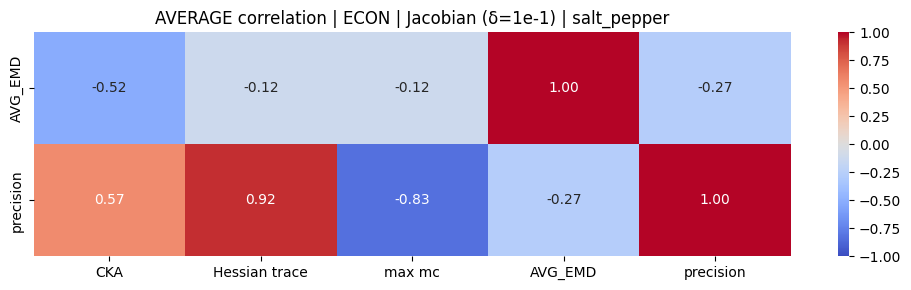

In [38]:
for noise_type in ["gaussian", "salt_pepper"]:
    for regularizer in ["Baseline", "Orthogonality (δ=1e-5)", "Jacobian (δ=1e-1)"]:
        
        corr_matrices = []
        
        for noise_module in [np.NaN, 1.0, 5.0, 10.0, 15.0, 20.0]:
                        # Handle NaN separately
            if np.isnan(noise_module):
                subset = metric_vs_noise_df[
                    (metric_vs_noise_df["regularizer"] == regularizer) &
                    (metric_vs_noise_df["noise_type"].isin(["clean", noise_type])) &
                    (metric_vs_noise_df["Noise module (%)"].isna())
                ]
            else:
                subset = metric_vs_noise_df[
                    (metric_vs_noise_df["regularizer"] == regularizer) &
                    (metric_vs_noise_df["noise_type"].isin(["clean", noise_type])) &
                    (metric_vs_noise_df["Noise module (%)"] == noise_module)
                ]

            # Skip empty subsets
            if subset.empty:
                continue
            corr = subset[
                ["CKA", "Hessian trace", "max mc", performance[model], "precision"]
            ].corr(method="spearman")
            
            corr_matrices.append(corr)

            # plt.figure(figsize=(10, 8))
            # plt.title(f"{model} with {regularizer} tested with {noise_type} ({noise_module}%) ")
            # sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
            # plt.show()
            # for m1, m2 in combinations(["CKA", "Hessian trace", "max mc", performance[model], noise_name[model], "precision"], 2):
            sns.scatterplot(data=corr, x="AVG_EMD", y="Hessian trace", palette='Set2', s=80)
            plt.show()
            
        if corr_matrices:
            # Align all DataFrames on the same row/column labels before averaging
            corr_mean = sum(corr_matrices) / len(corr_matrices)
            corr_mean = corr_mean.drop(index=["CKA", "Hessian trace", "max mc"])

            plt.figure(figsize=(10, 3))
            plt.title(f"AVERAGE correlation | {model} | {regularizer} | {noise_type}")
            sns.heatmap(corr_mean, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
            plt.tight_layout()
            plt.show()



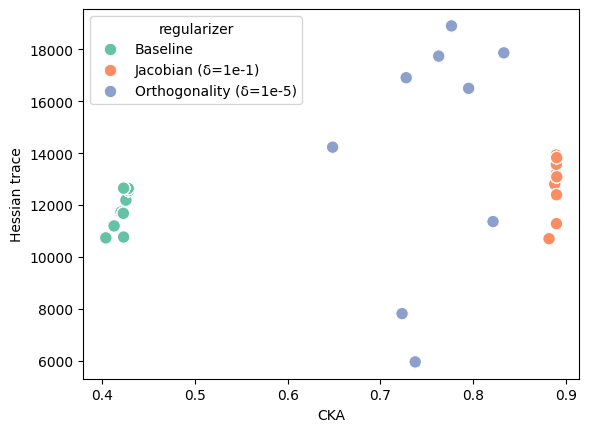

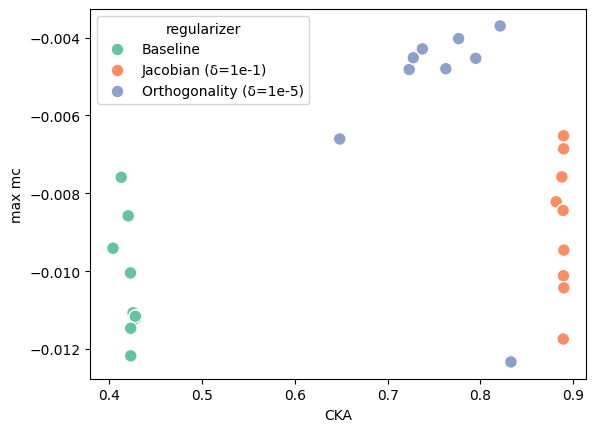

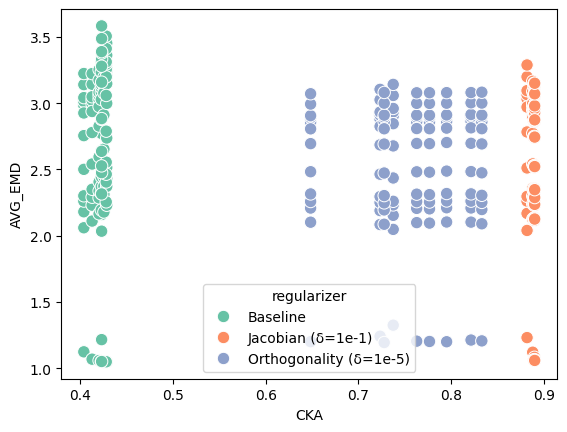

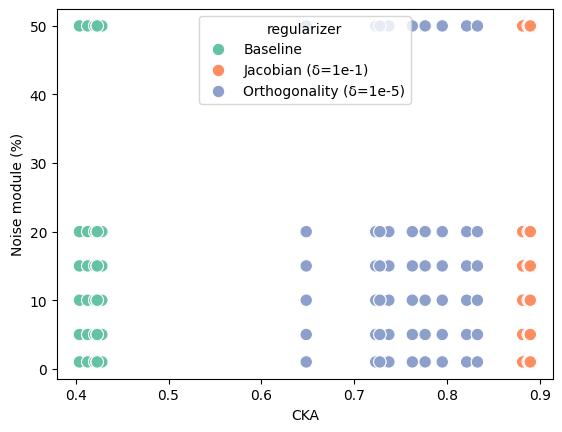

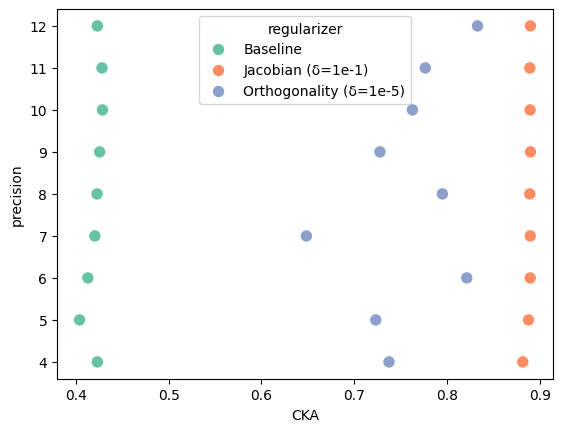

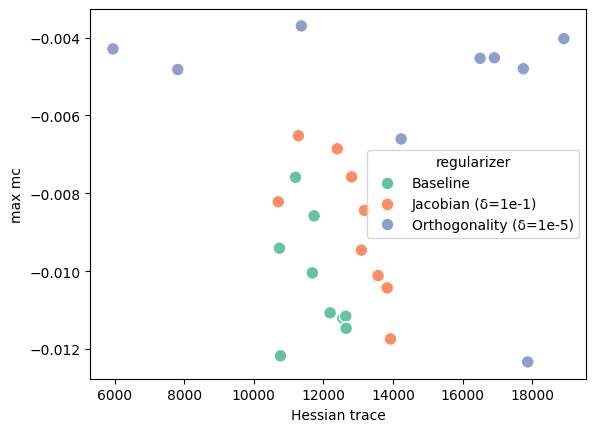

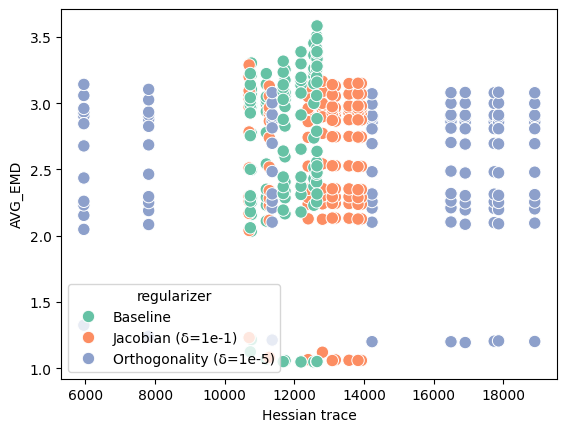

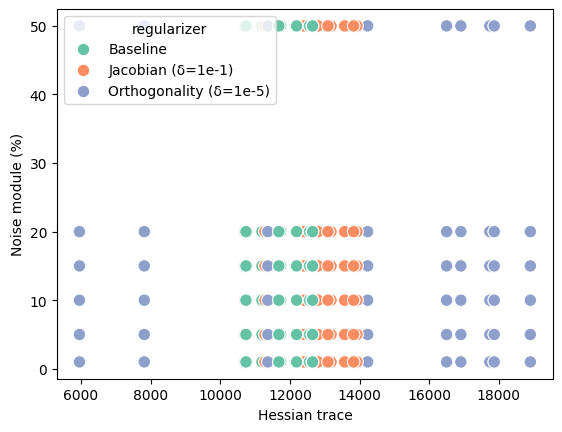

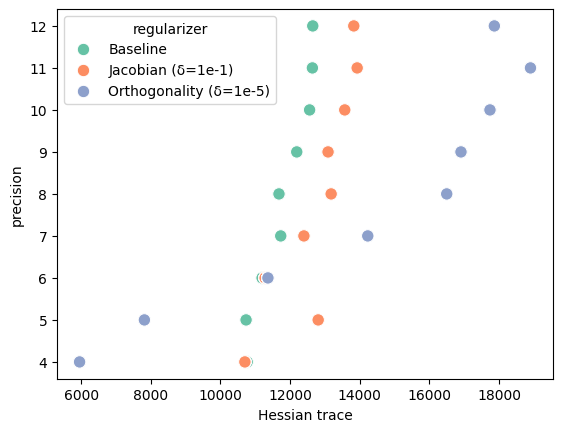

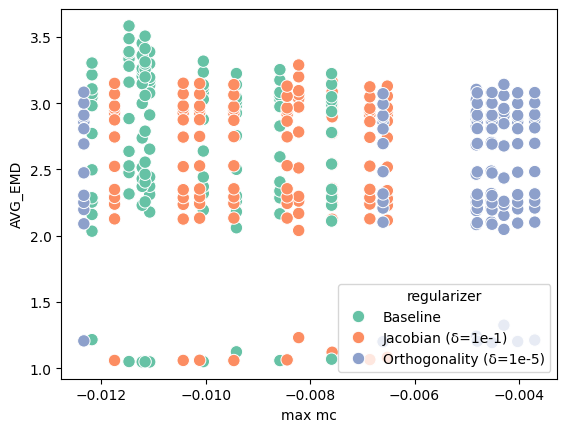

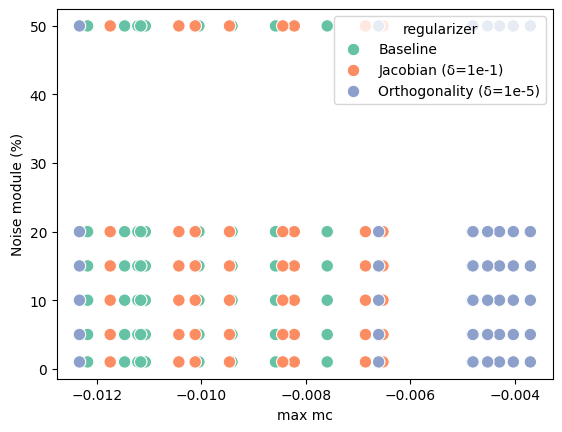

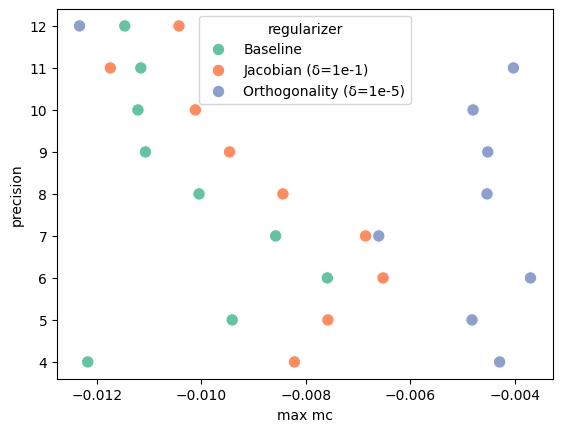

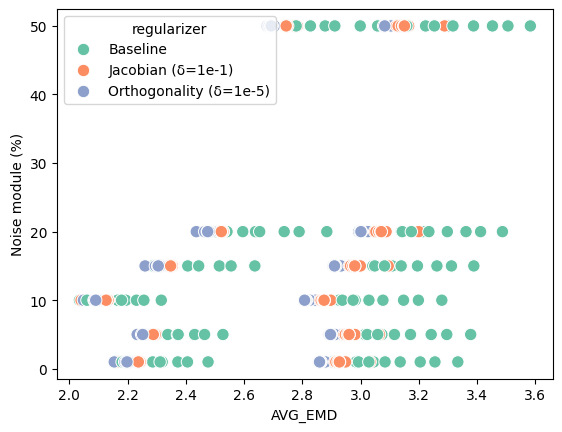

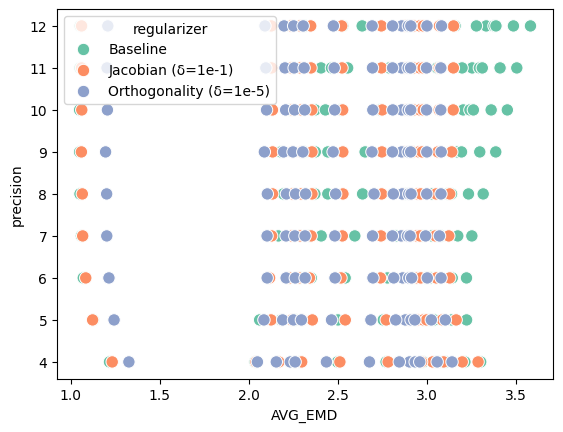

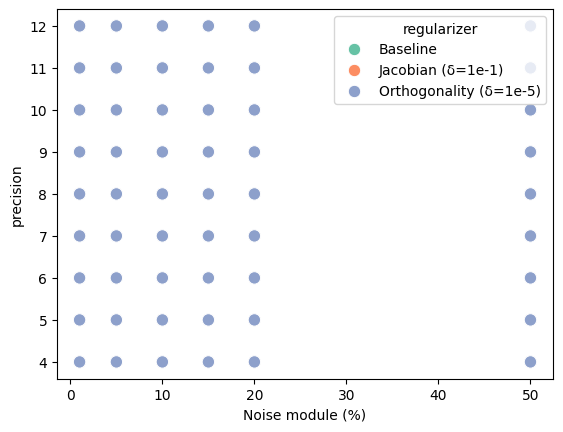

In [39]:
for m1, m2 in combinations(["CKA", "Hessian trace", "max mc", performance[model], noise_name[model], "precision"], 2):
    sns.scatterplot(data=metric_vs_noise_df, x=m1, y=m2, hue='regularizer', palette='Set2', s=80)
    plt.show()

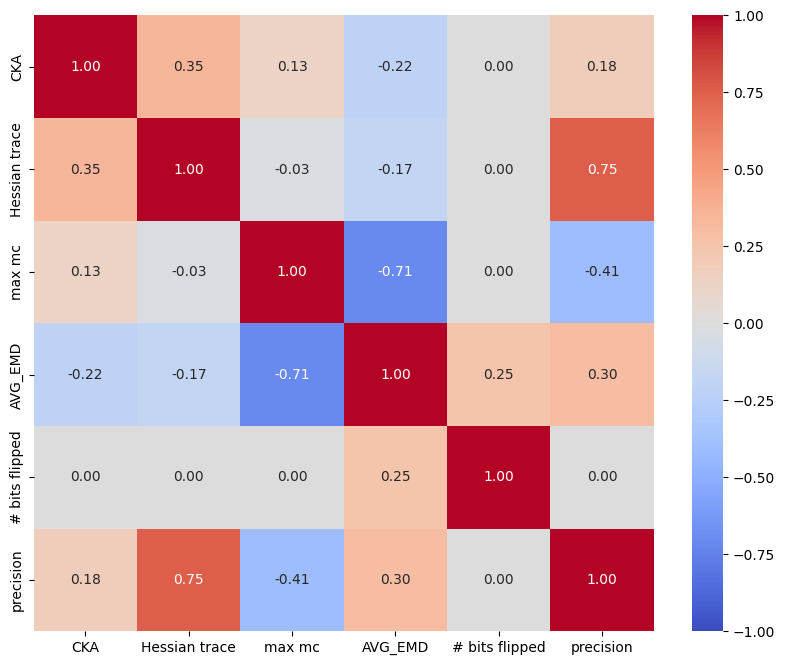

In [40]:
corr = metric_vs_weight_df[["CKA", "Hessian trace", "max mc", performance[model], "# bits flipped", "precision"]].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1., vmax=1.)
plt.show()

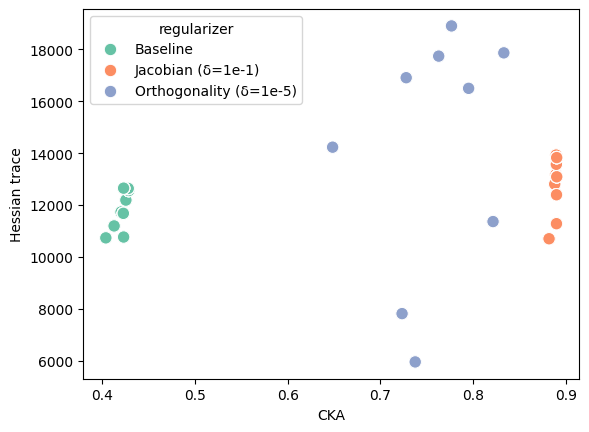

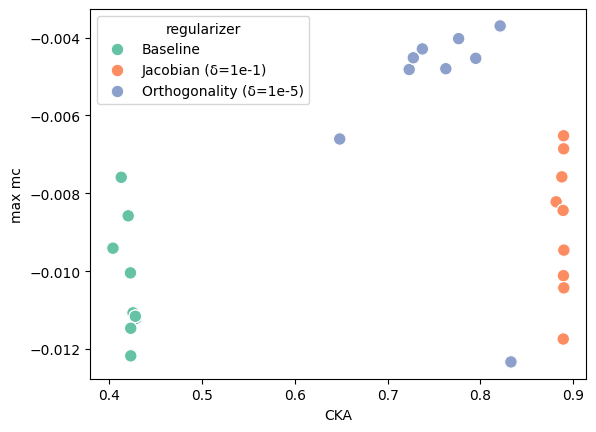

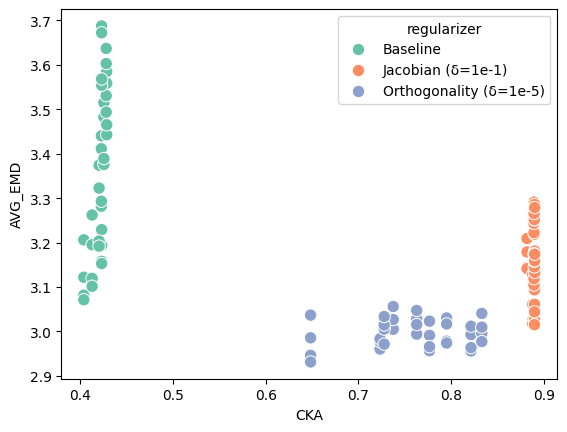

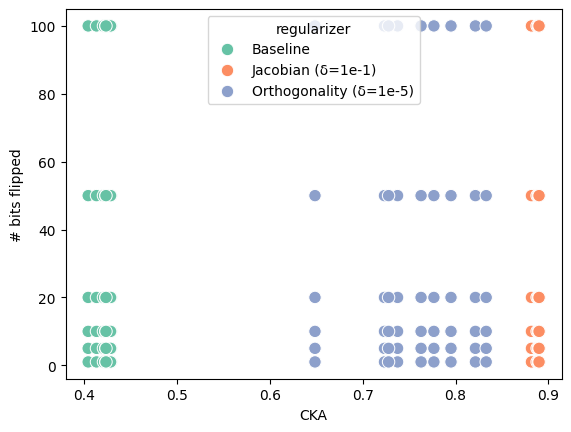

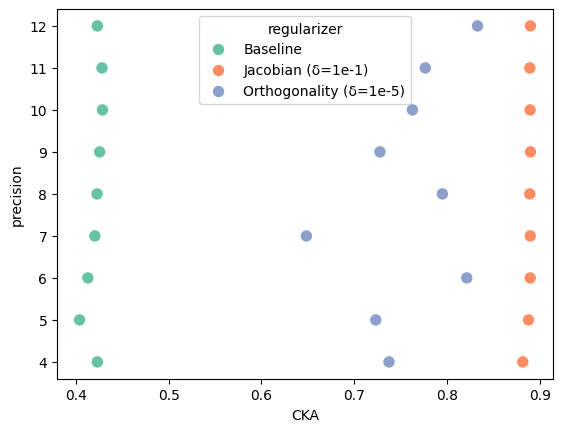

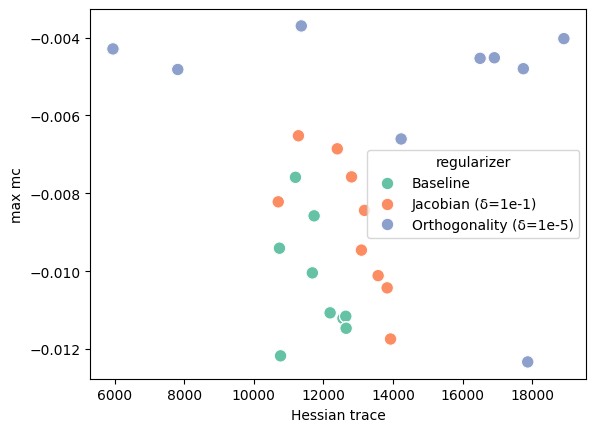

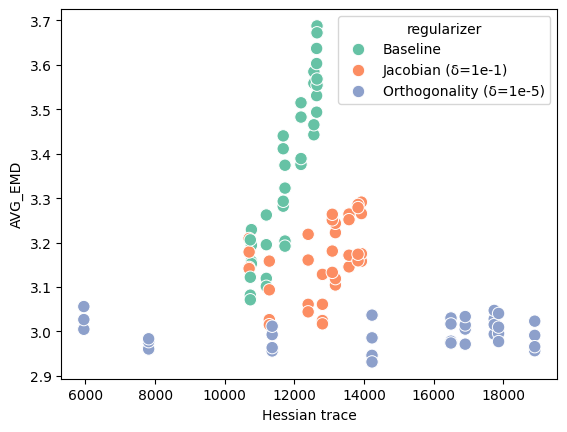

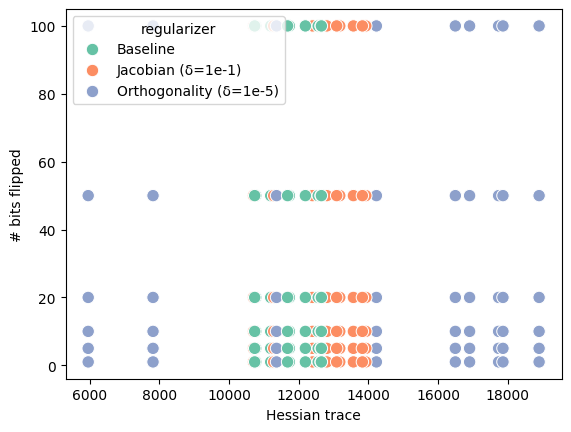

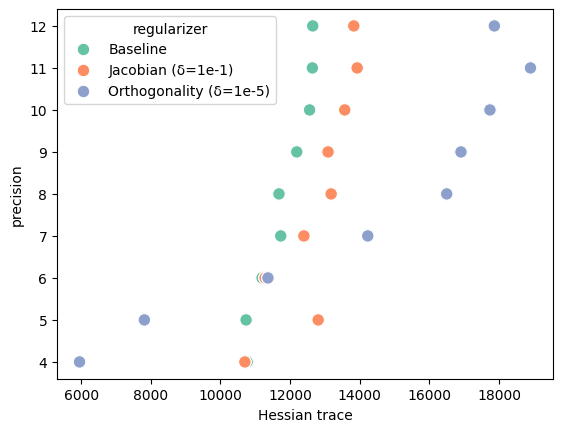

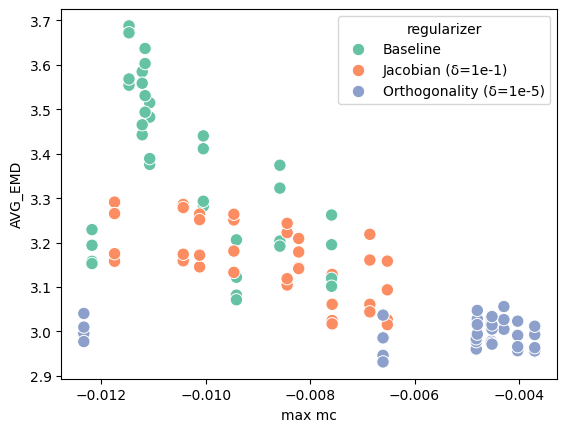

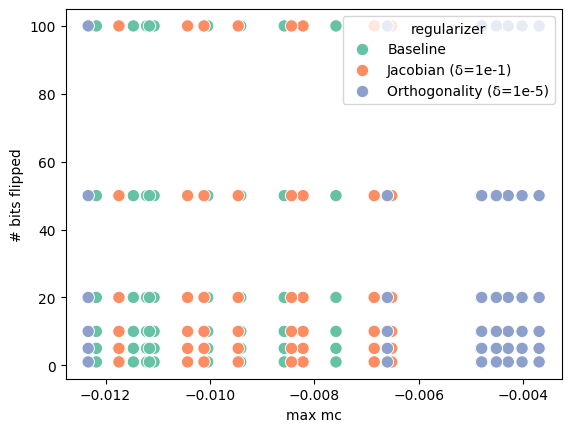

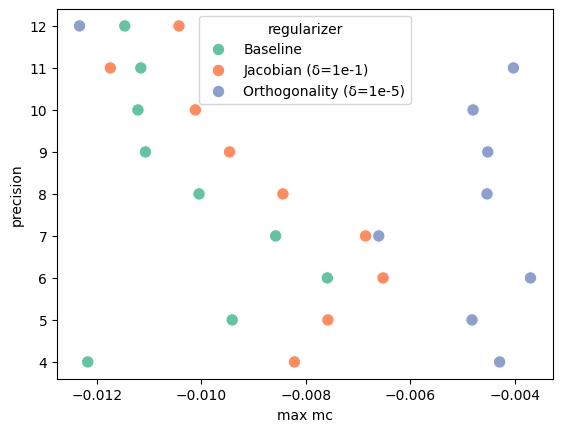

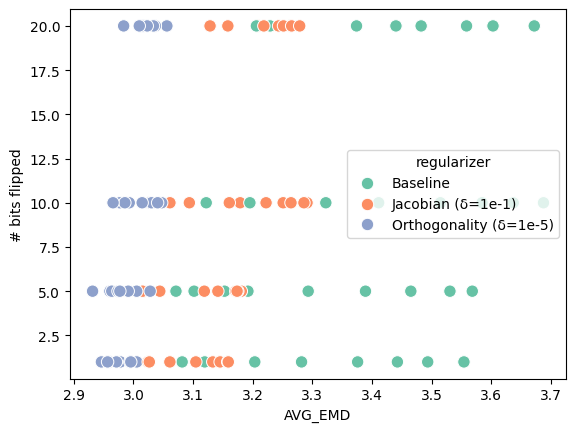

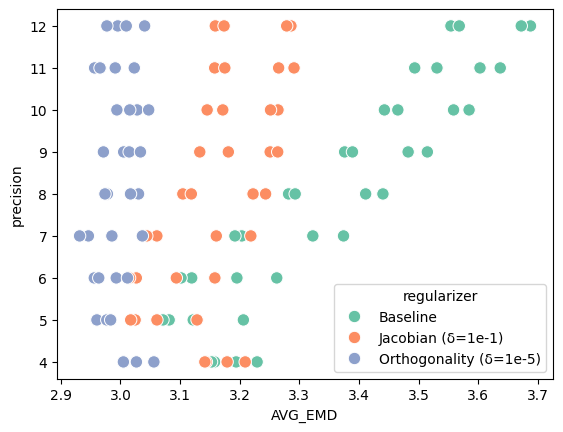

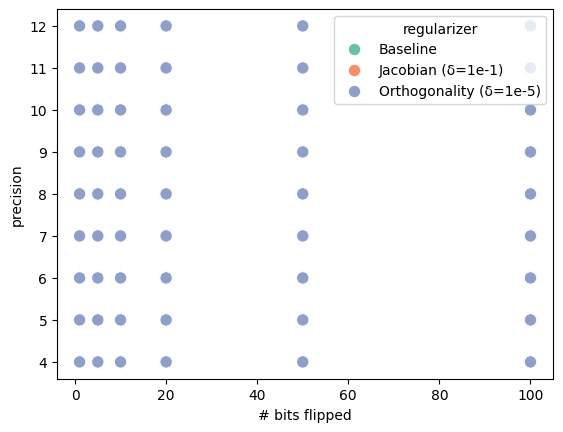

In [41]:
for m1, m2 in combinations(["CKA", "Hessian trace", "max mc", performance[model], "# bits flipped", "precision"], 2):
    sns.scatterplot(data=metric_vs_weight_df, x=m1, y=m2, hue='regularizer', palette='Set2', s=80)
    plt.show()